# Validation of Wikipedia Territorial Control Data Using ACLED
## Research Summary — Notebooks 05–07

This notebook summarises the complete validation analysis linking Wikipedia-derived territorial control labels to ACLED conflict event data for Myanmar. The Wikipedia ground-truth (`myanmar_wikipedia_temporal_groundtruth.csv`) provides manually curated territorial control labels for 352 towns across Myanmar, collected in 24 monthly snapshots from 2023-11-30 to 2026-03-30. ACLED provides daily geolocated conflict events with precise actor metadata. The central question is: **to what extent do ACLED territorial control events agree with, precede, or follow Wikipedia control labels?** The answer bears directly on how confidently Wikipedia can serve as ground-truth in quantitative conflict research, and which systematic biases a researcher should account for when using it.

In [1]:
from IPython.display import Image, display
from pathlib import Path
FIG = Path('/Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/reports/figures')

## Section 1 — Data Architecture & Coverage

### Wikipedia Ground-Truth Structure

The Wikipedia ground-truth dataset encodes manually curated territorial control labels at the town level, scraped from the Wikipedia article on the Myanmar civil war. The dataset has the following characteristics:

- **352 unique towns** with latitude/longitude point coordinates, **24 monthly snapshots**, yielding **8,035 total rows** (town × month observations).
- **Control statuses:** `government`, `resistance`, `ethnic_armed_group`, `contested`, `unknown`.
- The `contested` status is an **explicit Wikipedia label** — it is not derived or inferred. The actor field encodes who is contesting (e.g. "SAC vs NUG/PDF", "SAC vs Arakan Army"), providing additional detail about which actors are in conflict for that location.
- **LOCF (Last Observation Carried Forward) applied:** rows where `is_direct_snapshot=False` carry the previous direct snapshot's label forward to fill monthly gaps between Wikipedia updates. Critically, control **transitions can only be observed on direct-snapshot months** — LOCF months simply propagate the most recent known label and do not contribute independent information about control change.

### PRIOGRID Spatial Aggregation

Town-level Wikipedia labels are aggregated to the standard PRIO-GRID 0.5°×0.5° grid to enable comparison with ACLED events, which are similarly geo-referenced and can be joined to grid cells:

- **Cell assignment formula:** `gid = int((lat+90)/0.5)*720 + int((lon+180)/0.5)+1`
- **Cell centroid reconstruction:** `lon_centre = (col−1)×0.5−180+0.25`, `lat_centre = (row−1)×0.5−90+0.25`, where `col = ((gid−1) % 720) + 1` and `row = ((gid−1) // 720) + 1`.
- **185 unique PRIOGRID cells** have at least one Wikipedia town, covering Myanmar's most contested regions. The aggregated dataset is stored in `myanmar_priogrid_labels.csv` (5,238 cell-month rows).
- **Cell label = majority status** among all towns within that cell for the relevant month. Ties are resolved in favour of `contested` to avoid artificially assigning definitive control in ambiguous cases.

### ACLED Control Signal Definition

Not all ACLED events are informative about territorial control. To identify events that constitute a meaningful control signal, we flag four sub-event types as `is_control_signal=True`:

1. *Non-state actor overtakes territory*
2. *Government regains territory*
3. *Non-violent transfer of territory*
4. *Headquarters or base established*

In the Myanmar dataset, **637 total control signal events** are recorded. Of these, **390 fall within Wikipedia-covered PRIOGRID cells and within the Wikipedia observation window** (November 2023 – March 2026), making them eligible for agreement scoring. Each event is additionally coded with a `side` column mapping the reporting actor to either `Pro-junta` or `Anti-junta`, which is used for directional agreement scoring in Analyses 8 and 9.

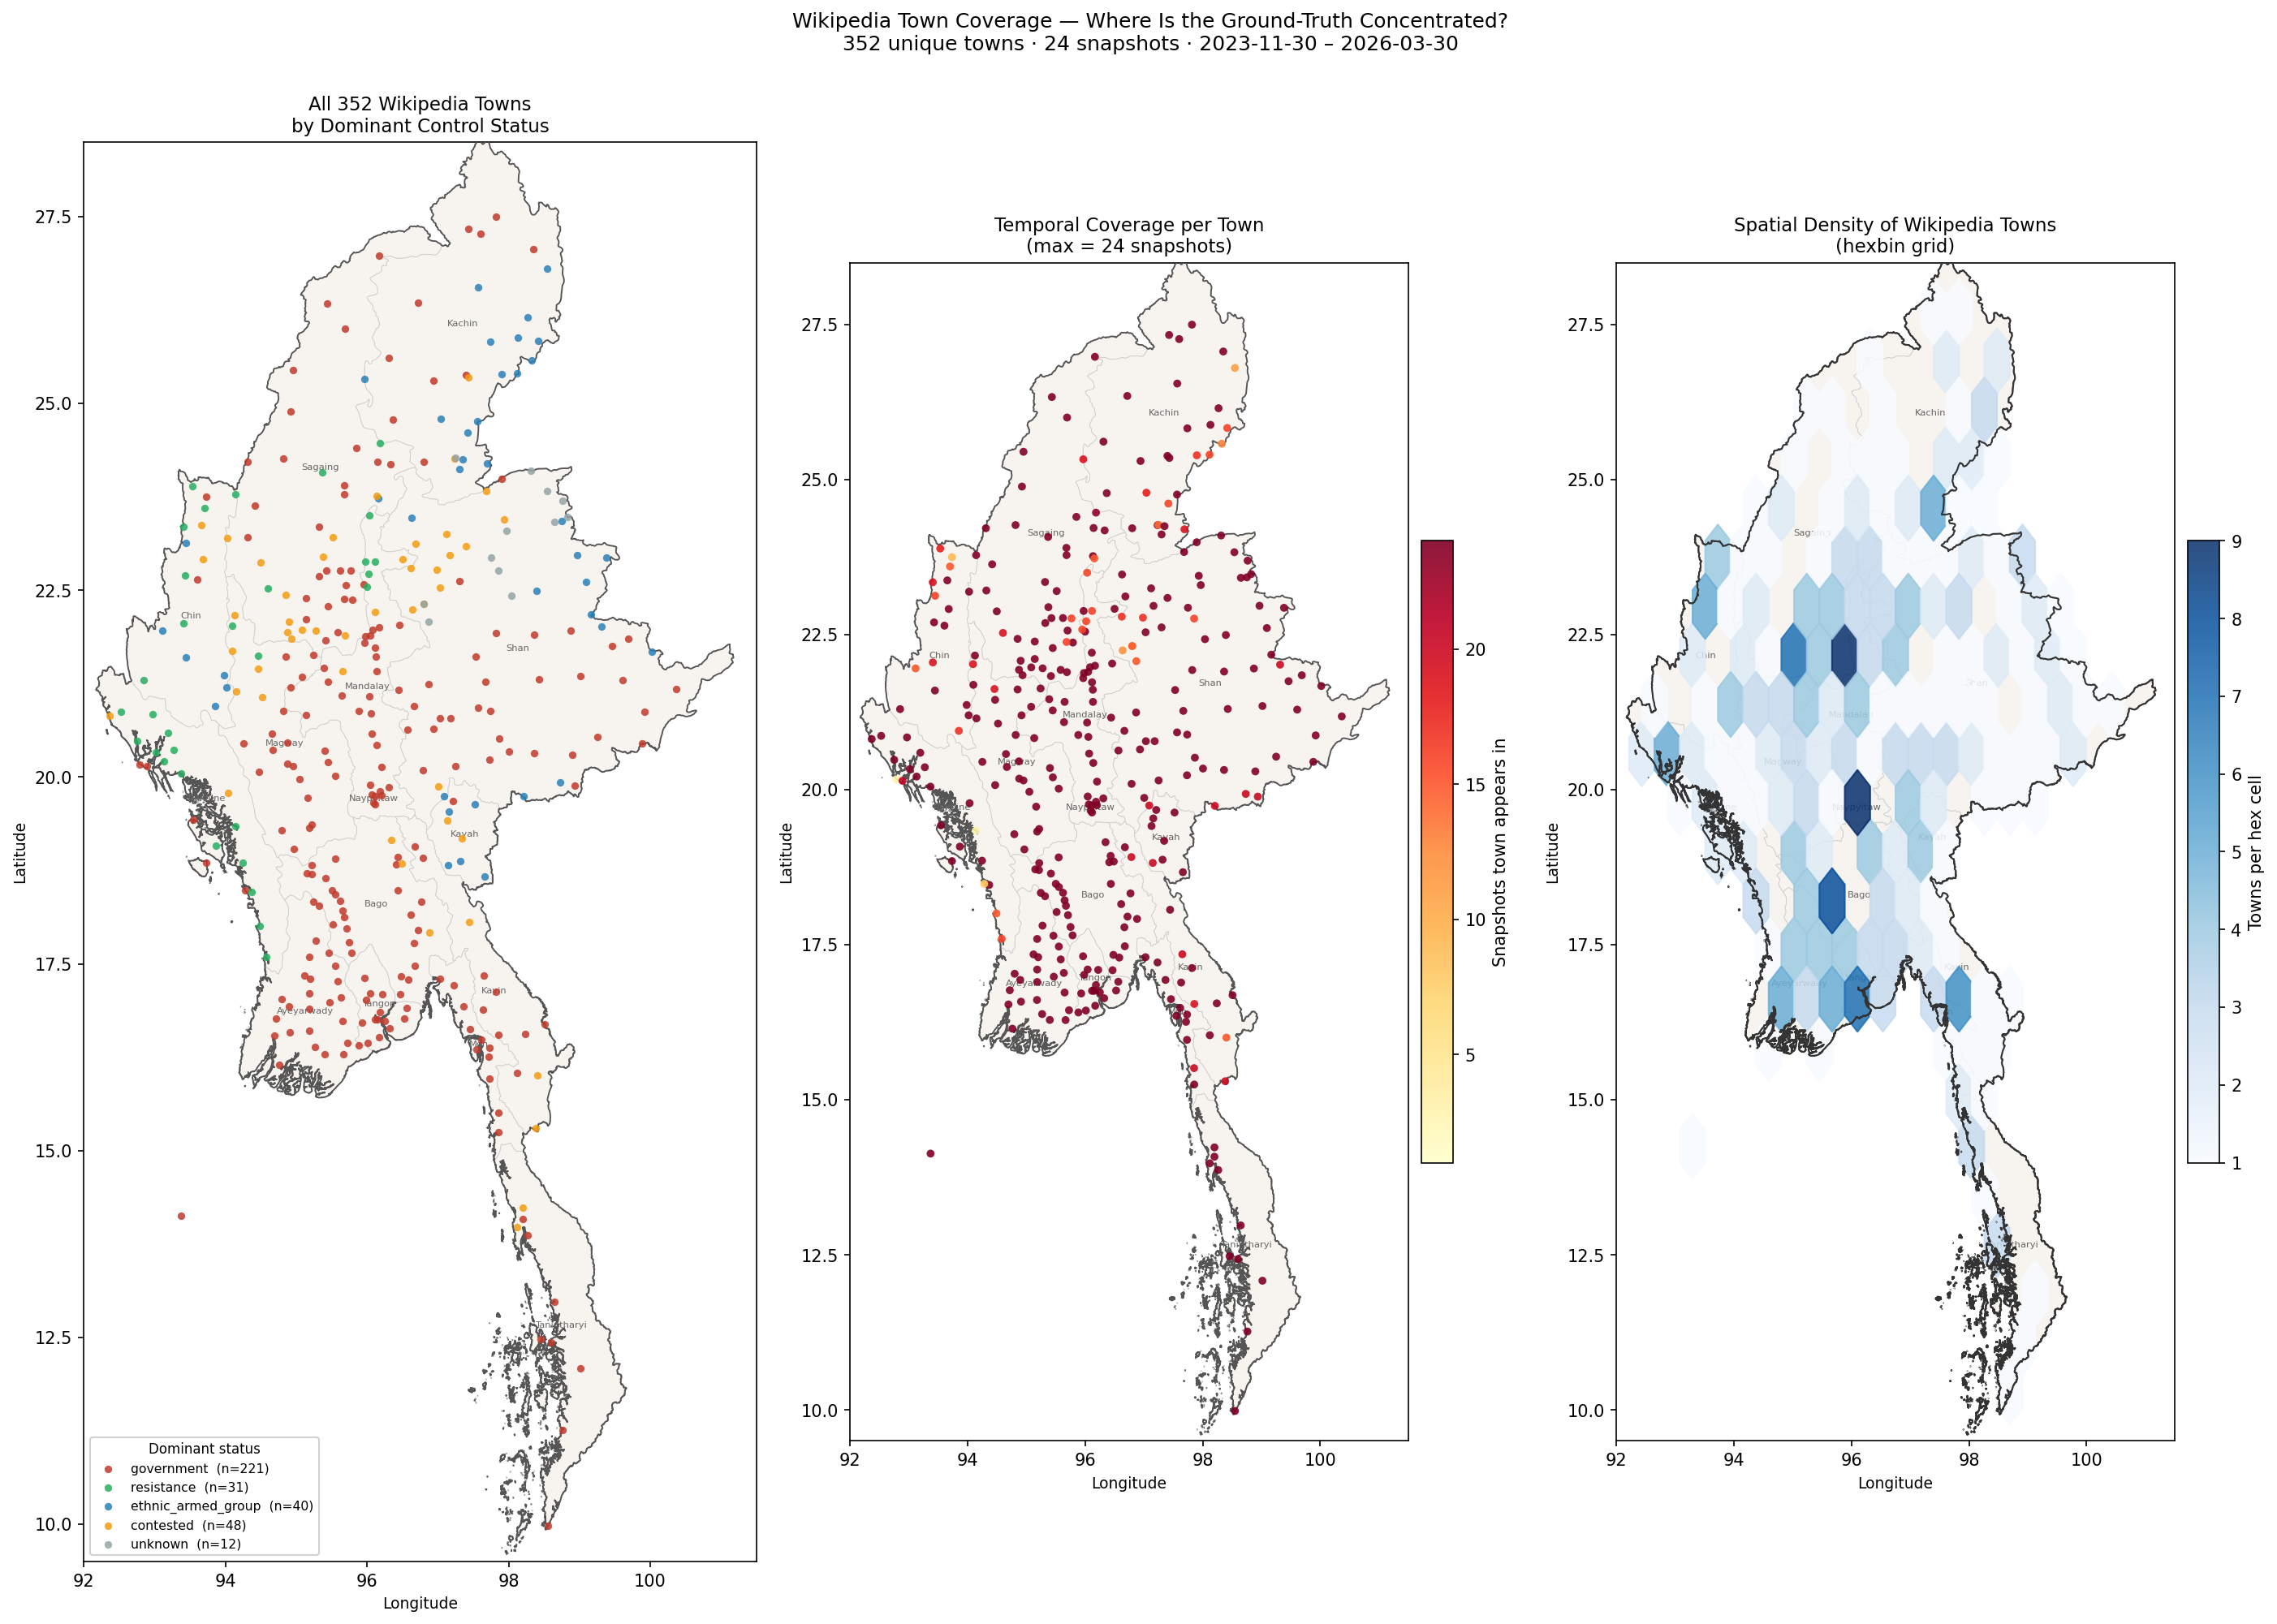

In [2]:
display(Image(str(FIG / 'wikipedia_town_coverage_map.png'), width=1200))

## Section 2 — Agreement Scoring Framework (Analyses 1–5)

### Agreement Score Definition

For each ACLED control-signal gain event, we compute how well the Wikipedia label at the matched cell-month agrees with the expected control outcome implied by the ACLED event. The scoring rule is:

| Score | Meaning |
|-------|---------|
| `1.0` | **Exact match** — Wikipedia label equals the expected controlling actor's side |
| `0.5` | **Partial credit** — Wikipedia shows `contested`; fighting is acknowledged but no clear controller assigned |
| `0.0` | **Mismatch** — Wikipedia shows a different side in clear control |
| `NaN` | **No data** — no Wikipedia observation available for that cell-month |

Two scoring granularities are computed in parallel to test sensitivity to spatial aggregation:

- **Cell-level (M+1):** The aggregated `myanmar_priogrid_labels.csv` status is used at the calendar month immediately following the ACLED event. This tests whether the PRIOGRID cell's majority label reflects the event within one month.
- **Town-level (nearest, 30 days):** A BallTree haversine search identifies the nearest Wikipedia town within ≤50 km of the ACLED event. The Wikipedia snapshot closest to `event_date + 30 days` is then scored. This allows finer spatial resolution but is subject to nearest-town selection bias.

### Analysis 1 — Distance Decay

Events are binned by distance from the ACLED event to the nearest Wikipedia town: 0–5, 5–15, 15–30, 30–50, and >50 km. The purpose is to test whether agreement scores drop as the spatial gap between the ACLED event and the Wikipedia reference point grows — which would indicate that spatial resolution is the primary explanation for low agreement.

**Finding:** The median distance from ACLED control event to nearest Wikipedia town is **1.8 km** — the vast majority of events are already proximate to a Wikipedia-covered location. Despite this, the full-match rate is low (~26%) even at the <5 km band. This rules out spatial resolution as the primary driver of disagreement. The problem is not that Wikipedia towns are too far from ACLED events; it is that even nearby towns show different control labels.

### Analysis 2 — Cell Homogeneity

For each PRIOGRID cell-month, homogeneity is defined as the fraction of towns within the cell that share the majority control label. High-homogeneity cells (all towns agree) are expected to yield cleaner agreement scores than mixed cells. The analysis tests whether internally consistent cells score higher.

**Finding (counterintuitive):** Pure cells score *lower* than mixed cells on average. Subsequent inspection reveals this is explained by the `no_wiki` category — cells with heterogeneous town coverage often have fewer data points, and the mix includes towns with no Wikipedia entry, which inflates apparent agreement on the subset that does match.

### Analysis 3 — Temporal Lag Sensitivity

Agreement scores are computed at multiple temporal offsets: M+0, M+1, M+2, M+3 at the cell level, and 0, 14, 30, 60, 90 days at the town level. This tests whether Wikipedia is simply a lagged confirmation of ACLED — i.e., whether scores improve substantially at longer lags as Wikipedia editors update their labels.

**Finding:** Scores improve marginally with lag but the improvement is small and plateaus quickly. Wikipedia is not simply "slow to update" in a way that would be corrected by waiting an extra month. The predominant form of disagreement is substantive rather than temporal — Wikipedia editors and ACLED coders apply different standards for what constitutes territorial control, particularly for non-state actor advances.

### Analysis 4 — Sub-Event Type × Actor Heatmap

A heatmap cross-tabulates mean agreement score by ACLED sub-event type (rows) against the top 9 most active actors (columns). This identifies which actor–sub-event combinations are best and worst captured by Wikipedia.

**Finding:** *Government regains territory* events score highest; *Non-state actor overtakes territory* events score lowest. This pattern is consistent with Wikipedia's well-documented editorial tendency to maintain government labels by default, lagging recognition of non-state gains relative to ACLED's event-level coding.

### Analysis 5 — Regional Breakdown (Admin1)

Agreement scores are aggregated by Myanmar state/region (Admin1 level) and displayed as both a choropleth map and a bar chart. This tests whether the sources are more concordant in some theatres than others.

**Finding:** Rakhine and Kayah show relatively higher agreement between ACLED and Wikipedia labels. Sagaing and Mandalay show the lowest agreement, consistent with the particularly fluid and complex conflict dynamics in those regions where multiple actors operate simultaneously and control changes rapidly.

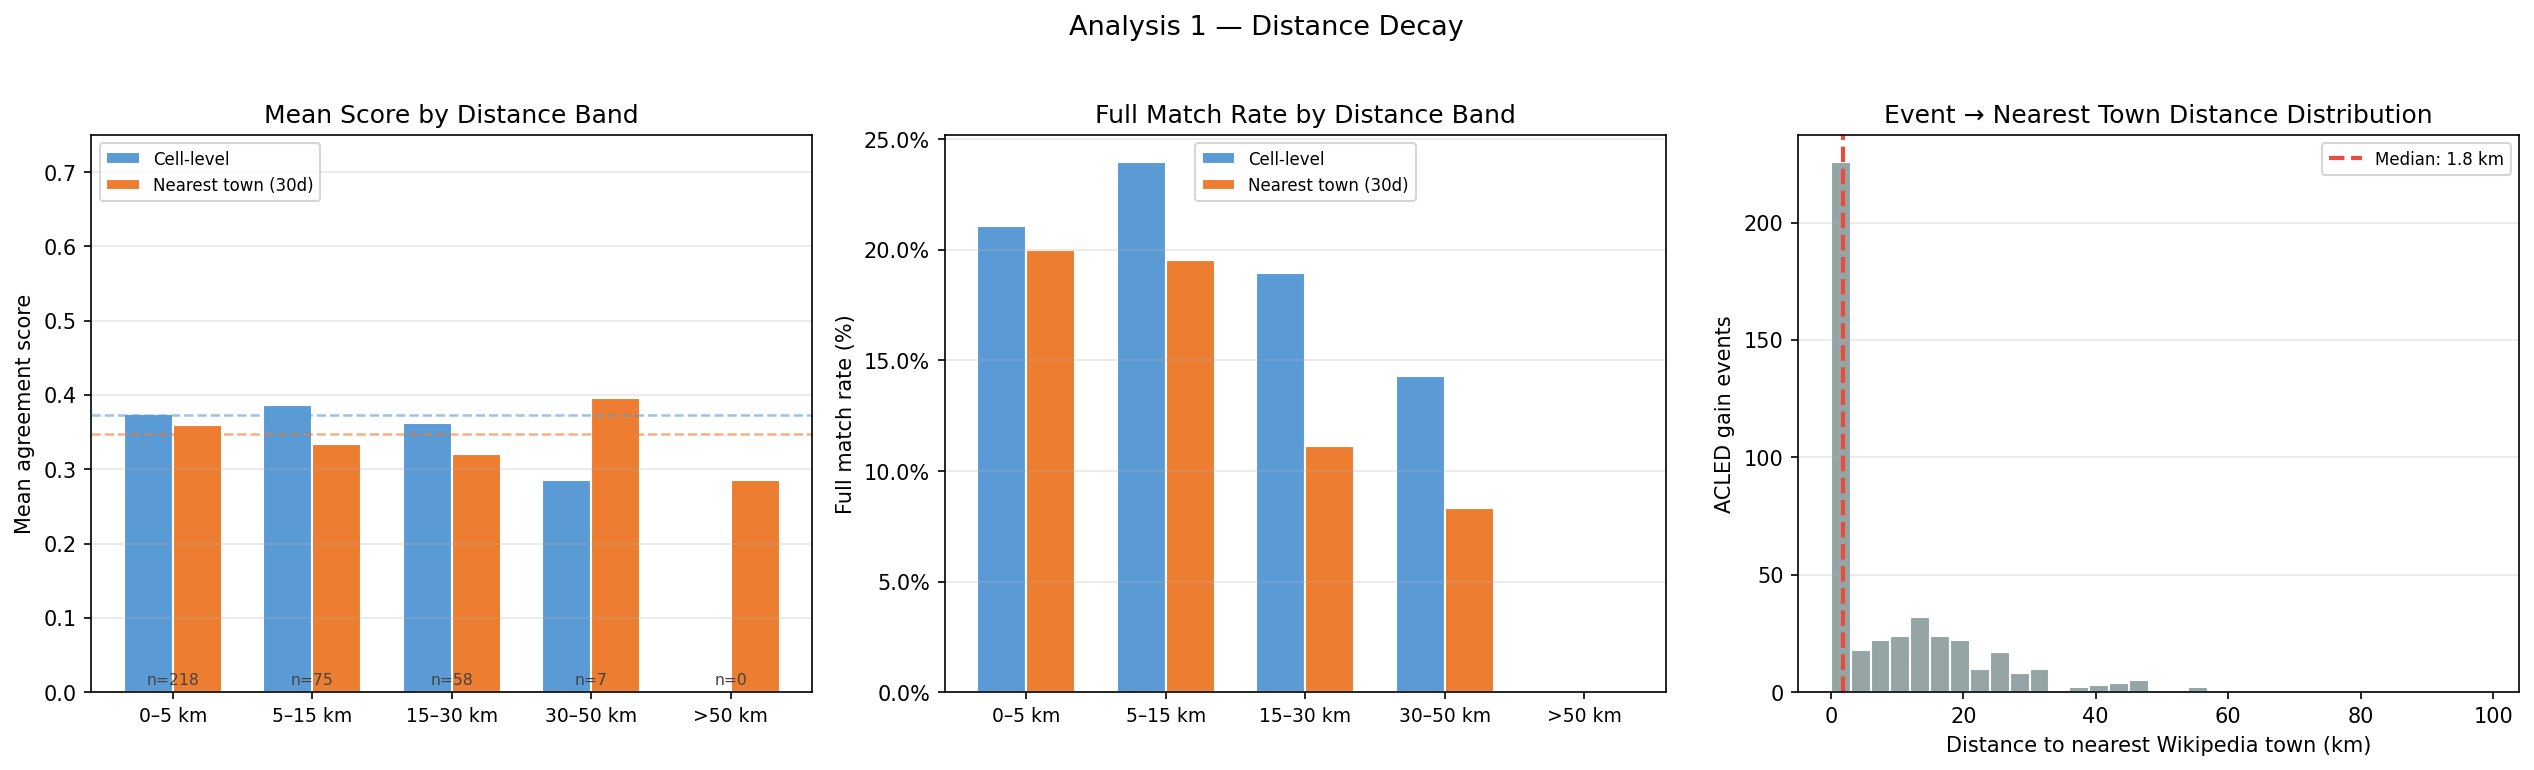

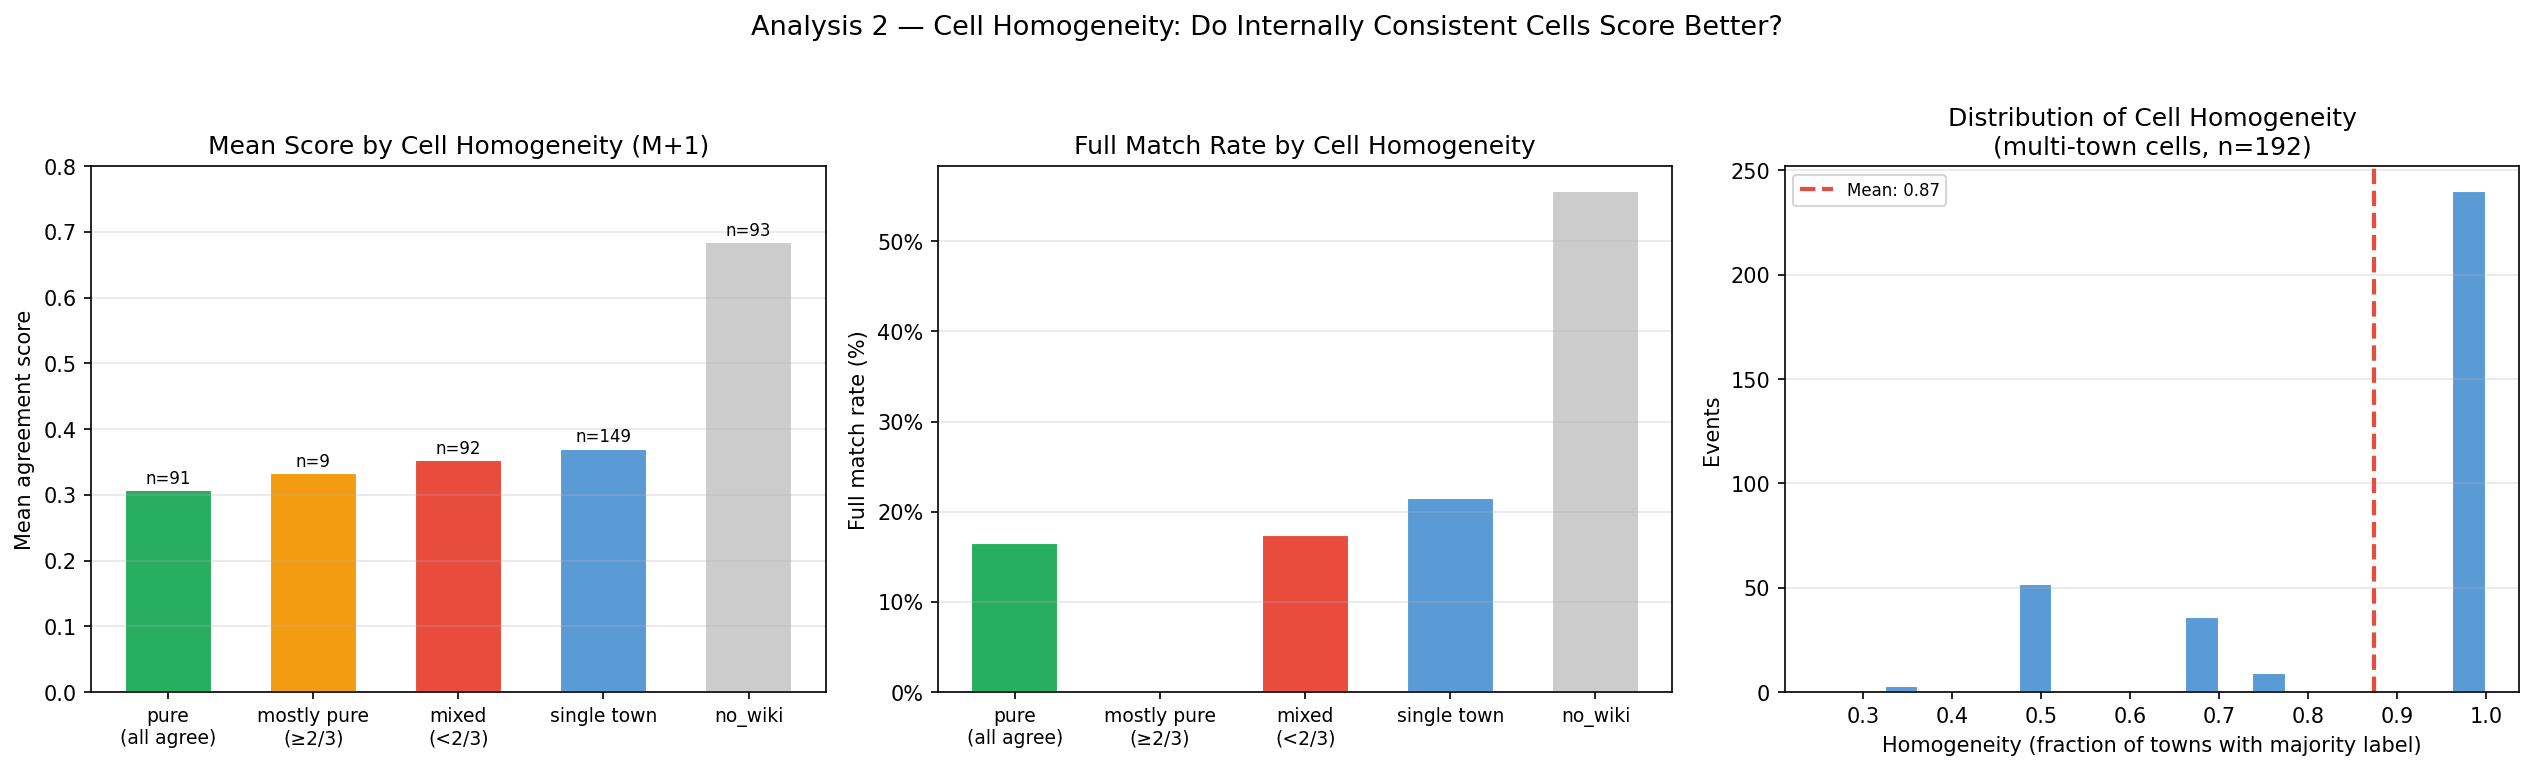

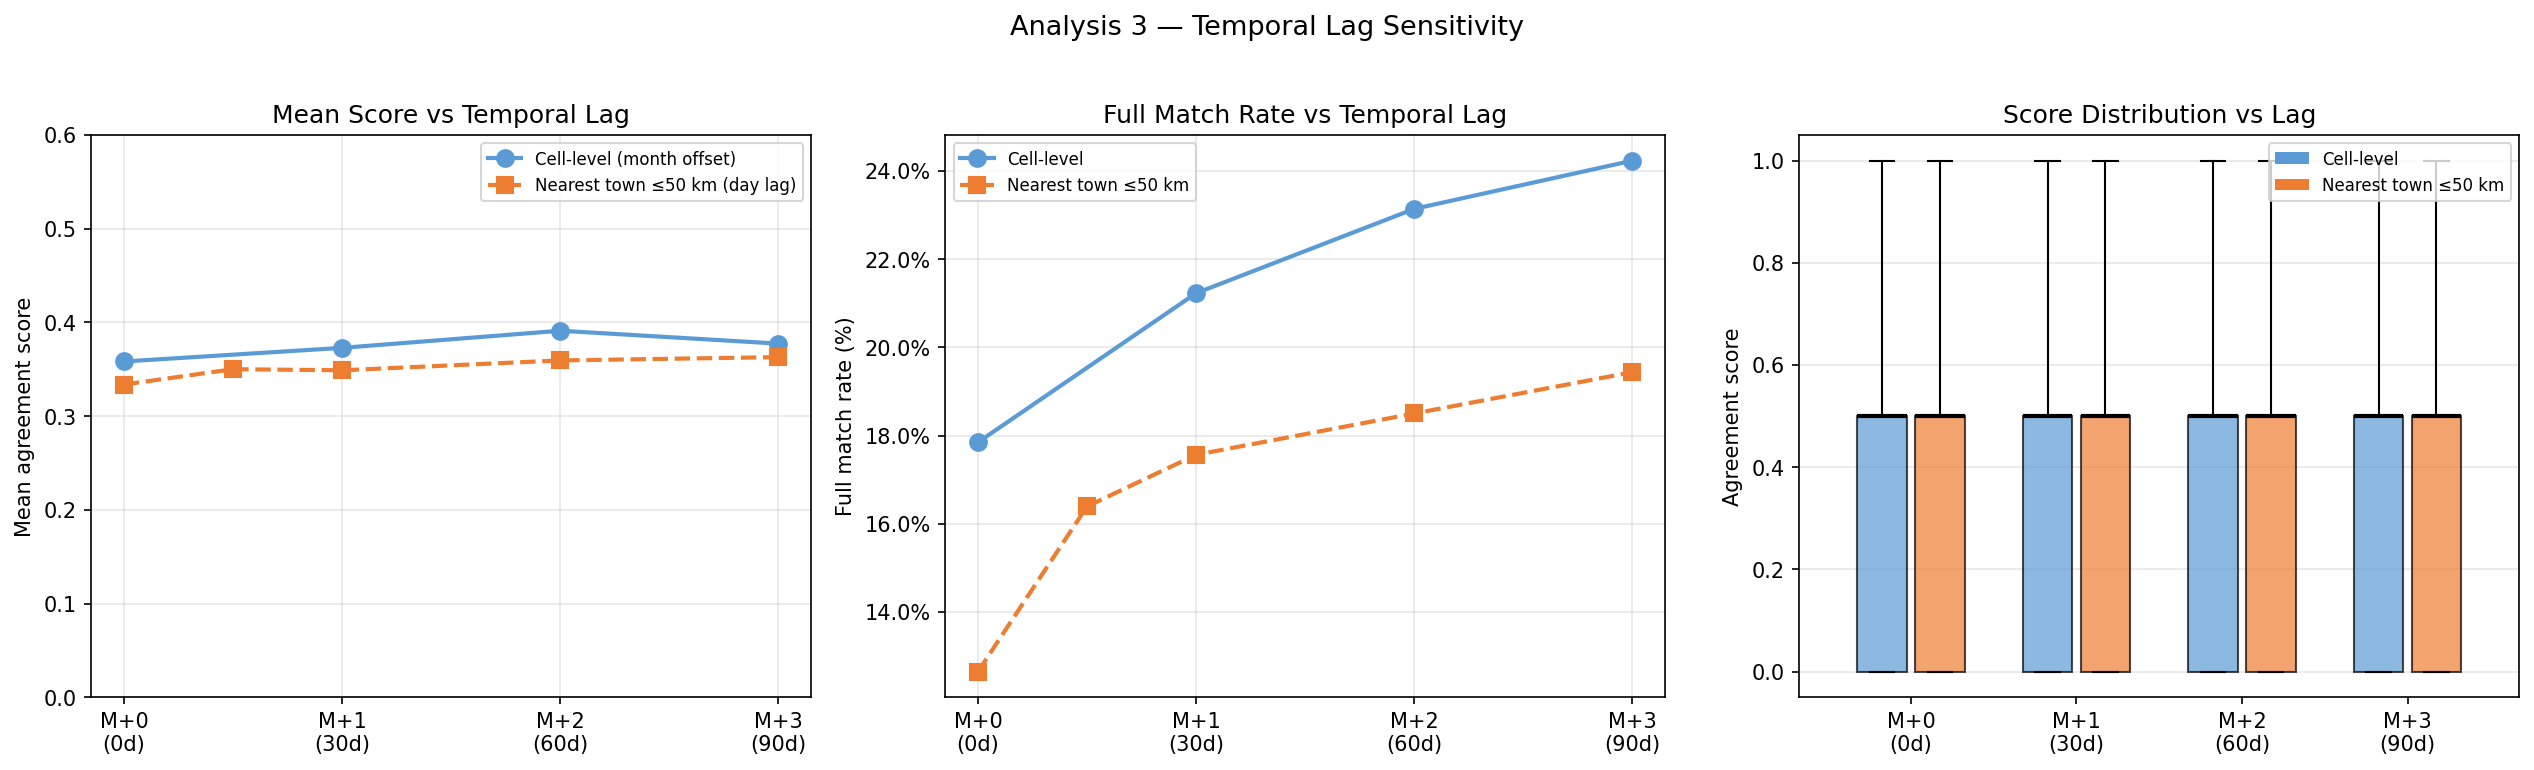

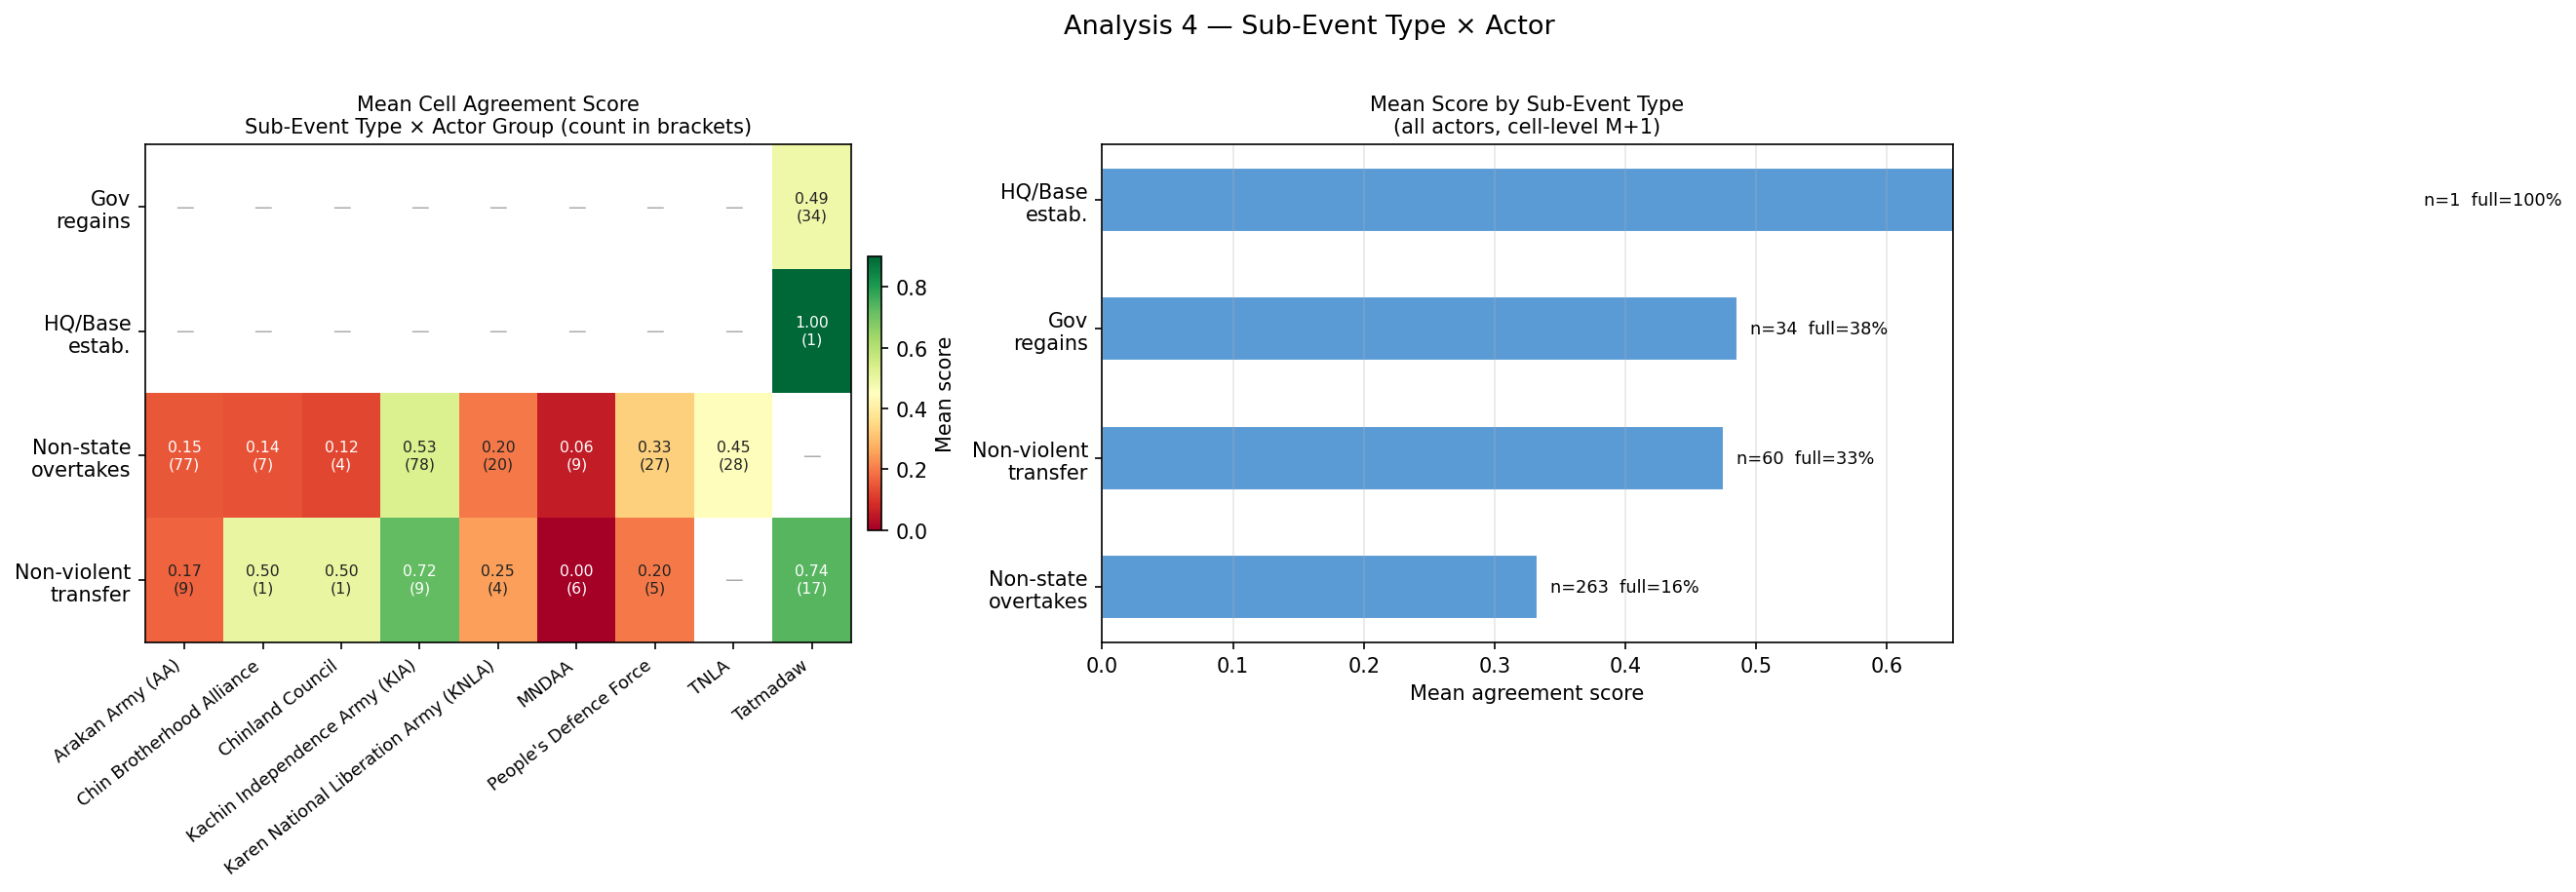

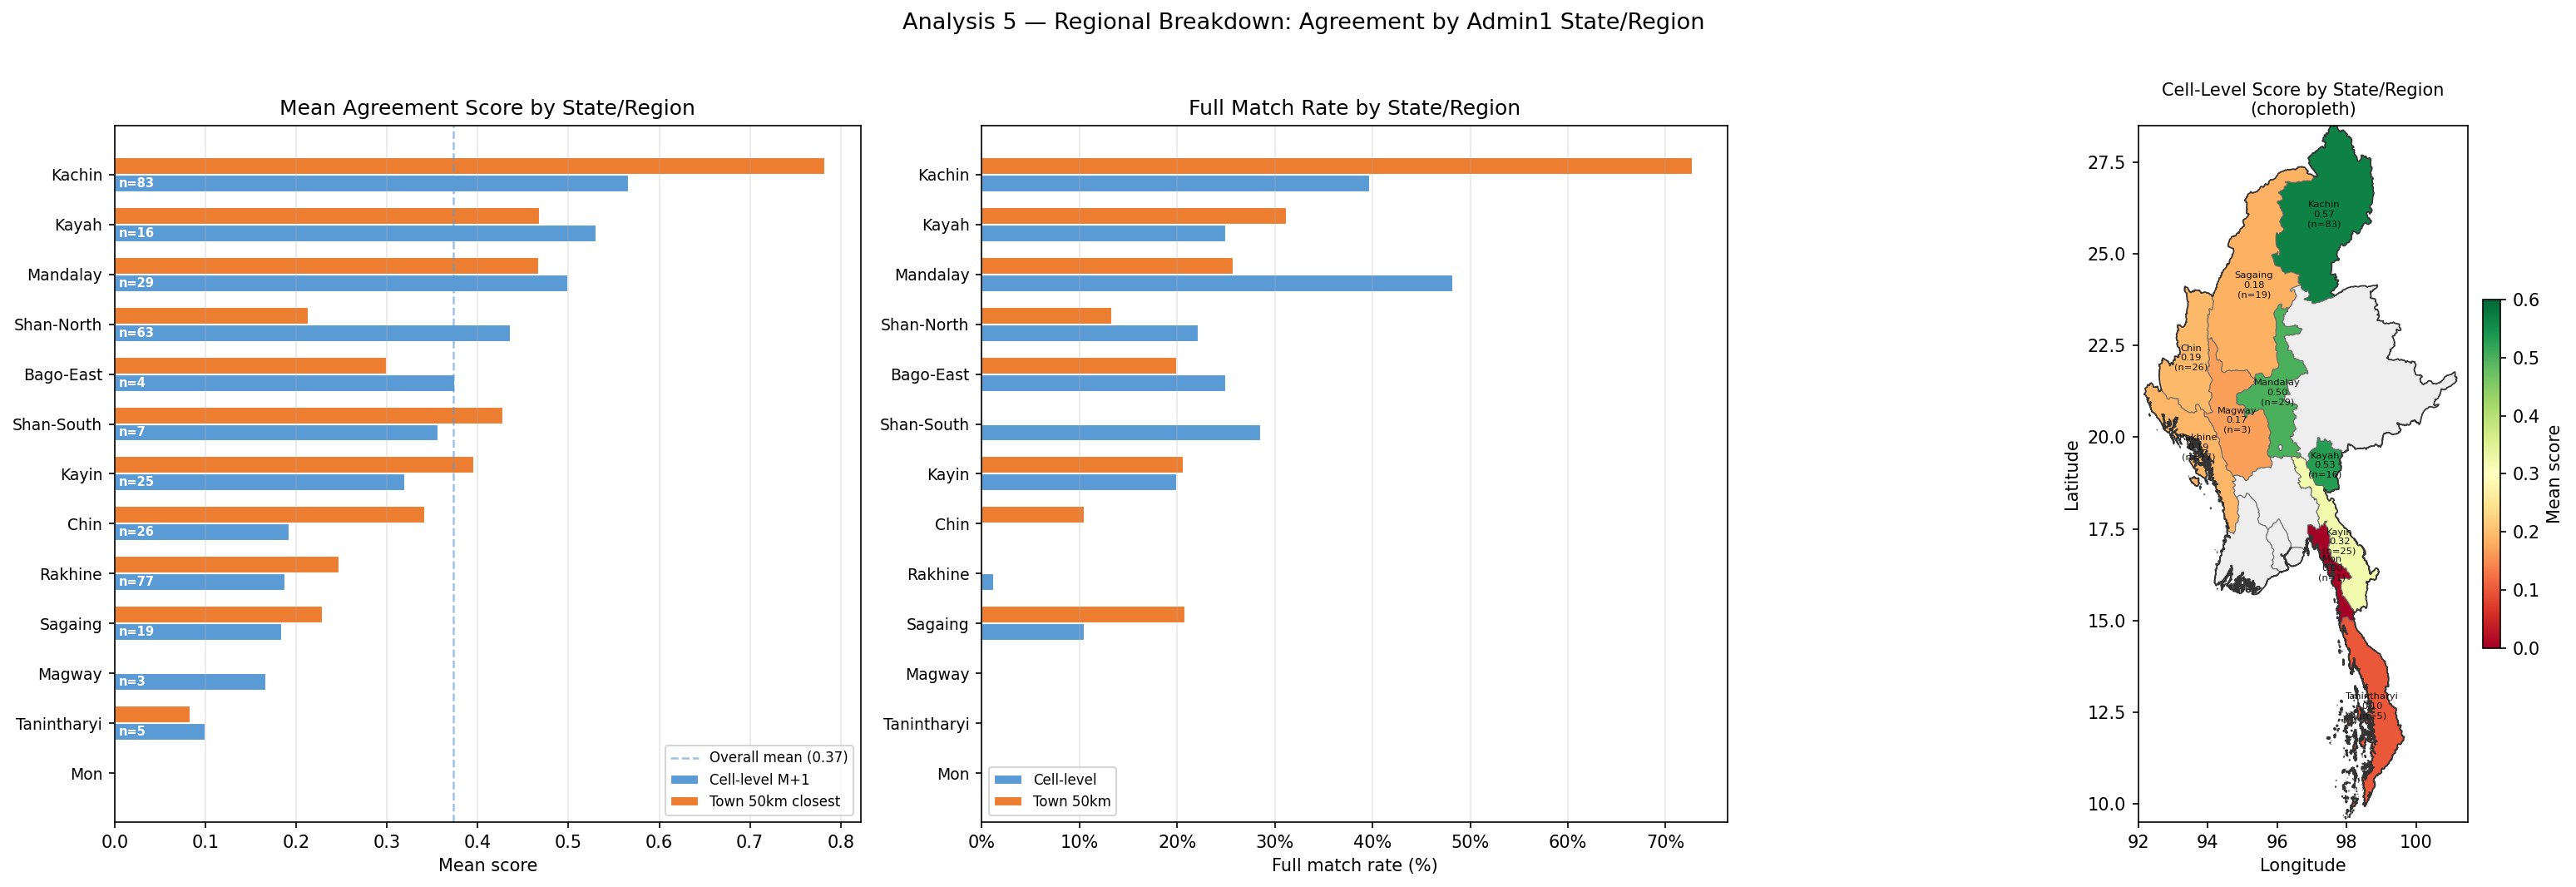

In [3]:
display(Image(str(FIG / 'analysis1_distance_decay.png'), width=1200))
display(Image(str(FIG / 'analysis2_cell_homogeneity.png'), width=1200))
display(Image(str(FIG / 'analysis3_temporal_lag.png'), width=1200))
display(Image(str(FIG / 'analysis4_subtype_actor.png'), width=1200))
display(Image(str(FIG / 'analysis5_admin1.png'), width=1200))

## Section 3 — Control Cell Dynamics (Analysis 6)

### What We Measured

Independent of any ACLED comparison, we characterise how dynamic the Wikipedia cell labels themselves are. This establishes a baseline for the ground-truth's internal volatility before asking whether ACLED precedes or confirms Wikipedia changes. Without this baseline, it is impossible to distinguish between ACLED being a poor predictor of Wikipedia and Wikipedia simply not changing much.

### Method

Using `myanmar_priogrid_labels.csv`, a transition is defined as any cell-month where `control_status ≠ prev_control_status` (comparing to the previous calendar month for the same cell). Importantly, **only direct-snapshot months can produce genuine transitions** — LOCF months simply carry forward the prior label and are excluded from transition detection to avoid spurious "no-change" inflation.

The following metrics are computed:

- **Monthly change rate:** number of cells showing a transition ÷ total cells with data, per month. Provides a time-series view of when control changes are most frequent.
- **Transition matrix:** both raw counts and row-normalised probabilities of each status-to-status transition. Reveals which transitions are most common (e.g. government → contested vs. resistance → government).
- **Spell duration distribution:** consecutive runs of the same status per cell, measured in months. A short median spell means the label is volatile; a long median means it is stable.
- **Stability rate by status:** fraction of cell-months for each status where the label did NOT change from the prior month. Distinguishes structurally stable statuses (government) from fluid ones (contested).
- **Per-cell change count:** total number of status transitions over the observation window, mapped geographically to identify volatile regions.

### Key Findings

**101 total transitions** are observed across 185 cells over 29 months — a transition rate of approximately **1.9% of cell-months**. The ground-truth is thus relatively stable: most cells do not change label within the observation window.

The dominant transition is **Government → Contested** (41 cases), reflecting frontline cells where Wikipedia recognises an ongoing challenge to government control. The reverse transition (Contested → Government, i.e. stabilisation) is less frequent, suggesting that once a cell enters the contested category in Wikipedia it tends to remain there or shift further toward non-state control rather than reverting.

**Government spells** are the longest (median 29 months — meaning many cells have been government-controlled for the entire observation window). **Ethnic armed group and resistance spells** have median durations of approximately 20 months, indicating that once non-state actors consolidate control Wikipedia reflects this durably.

**Geographically**, volatile cells — those with two or more label changes — concentrate in **Rakhine State** (consistent with the Arakan Army's rapid advances) and **Sagaing Region** (consistent with PDF operations against junta positions).

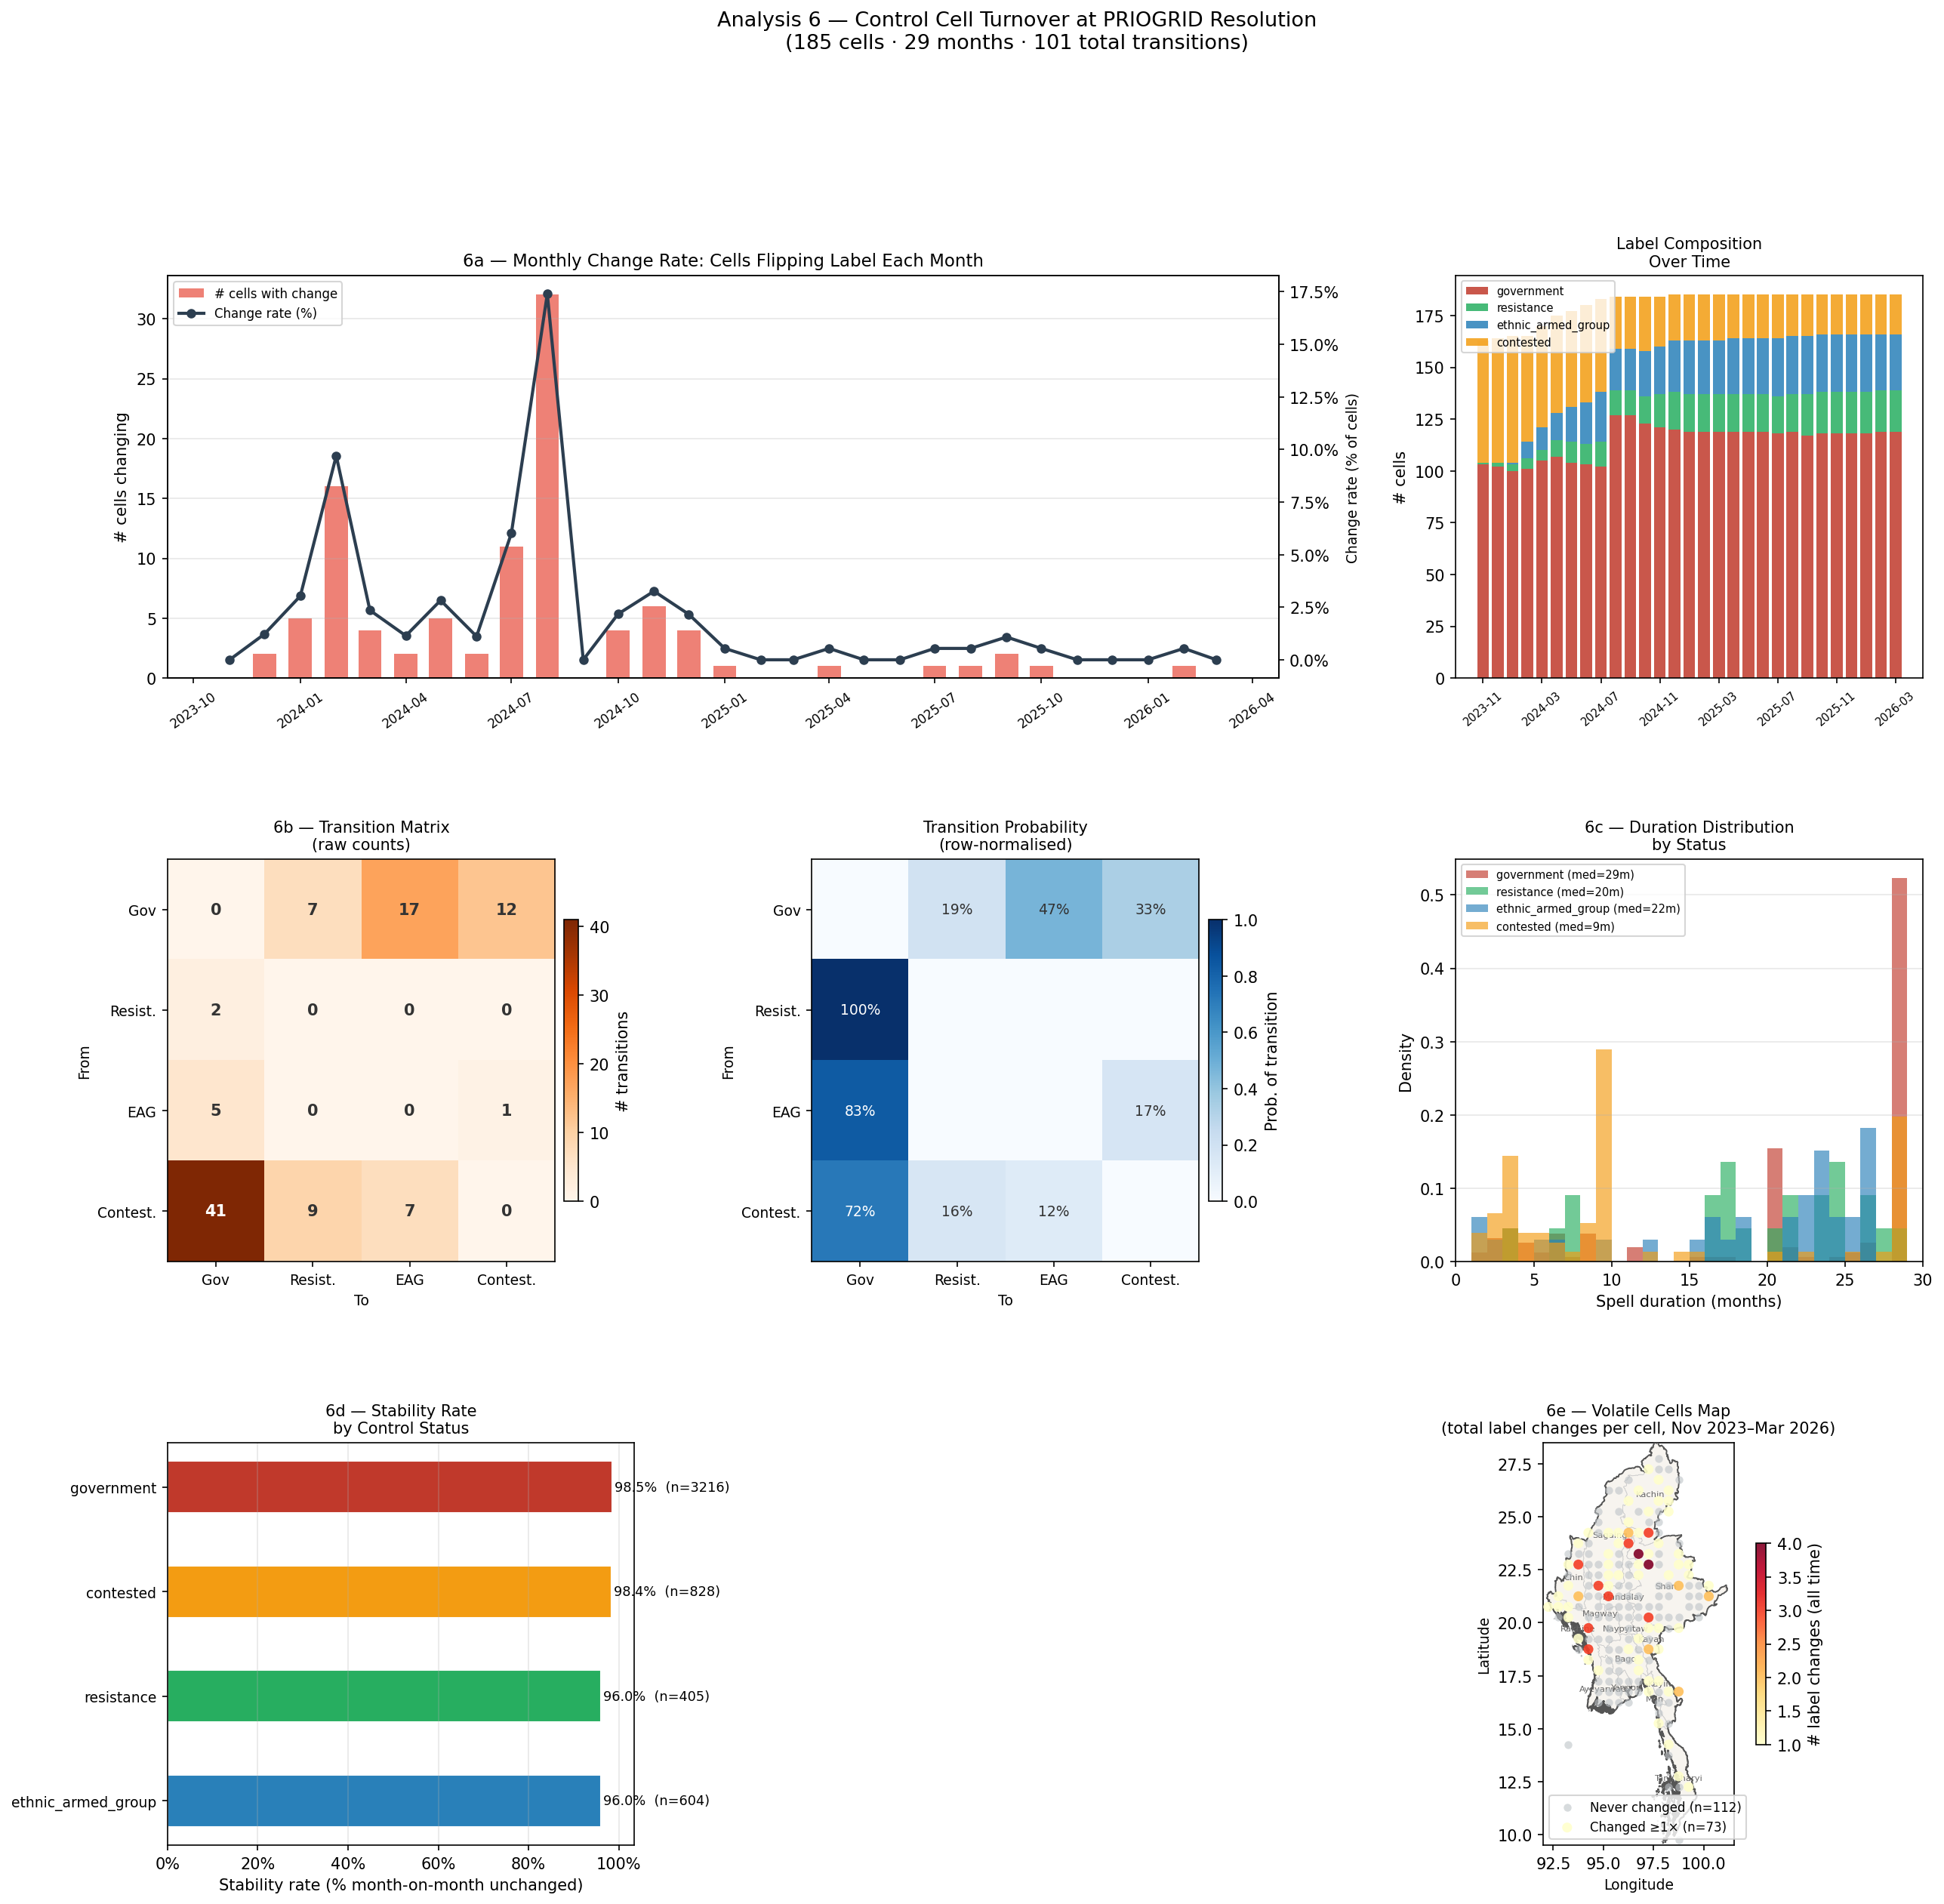

In [4]:
display(Image(str(FIG / 'analysis6_cell_turnover.png'), width=1200))

## Section 4 — ACLED as Leading Indicator: Do Control Events Precede Wikipedia Transitions? (Analyses 7–8)

### Research Direction

The analyses in this section reverse the direction of inquiry: instead of scoring ACLED events against Wikipedia, we start from **Wikipedia transitions** and look backward in time at ACLED. If ACLED is a genuine leading indicator of territorial control change, then cells that change their Wikipedia label at month M should show elevated ACLED activity in months M−1 through M−6 — particularly control-signal sub-event types.

### Sample Construction (Analysis 7)

From the 101 total Wikipedia cell-level transitions, we restrict to **non-contested transitions**: both `prev_status` and `control_status` must differ from `contested`. This leaves **31 clean control changes**.

The rationale for excluding contested-boundary transitions is substantive: transitions such as `government → contested` or `contested → resistance` are fundamentally different phenomena from a clean `government → resistance` flip. The former reflects a cell *entering or exiting a contested state* (a frontline classification), not a definitive transfer of control. Including them would conflate two distinct processes and reduce the interpretability of the leading-indicator test.

For each of the 31 qualifying transitions at month M, we count ACLED events in the same PRIOGRID cell at lags M−1 through M−6, using pre-aggregated cell×month lookup dictionaries for four event measures:

1. **Any events** (all ACLED event types)
2. **Battle events** (sub-events classified under the Battles event type)
3. **Control signals** (the four flagged sub-event types described in Section 1)
4. **Fatalities** (total reported fatalities in that cell-month)

**Coverage metric:** The percentage of the 31 transitions that had at least one ACLED event of the relevant type at each lag.

### Findings (Analysis 7)

- **Any-event coverage** peaks at **M−1 (61%)** and decays gradually to approximately 42–55% at longer lags. This confirms that ACLED does have some preceding signal before Wikipedia transitions, but coverage is incomplete.
- **Battle coverage** follows the same pattern with slightly lower absolute rates, consistent with the fact that not all ACLED events in these cells are battles.
- **Control-signal coverage** is sparse — maximum 16% at M−1 — reflecting the small total number of control-signal events (637 in the full dataset). With n=31 transitions, this coverage is too low to draw directional conclusions from control signals alone.

The decay pattern across lags (M−1 > M−2 > M−3 > …) is consistent with ACLED being a genuine leading indicator rather than coincident noise, but the incompleteness (~39% of transitions have no ACLED signal even in M−1) indicates that ACLED does not capture all Wikipedia-documented control changes.

### Analysis 8 — Direction Matching

Of the 31 non-contested transitions, 9 had at least one ACLED control-signal event in the M−1/−2/−3 window. For these 9 cases, we test whether the ACLED event's implied direction matches the Wikipedia transition direction:

- **`side_match`:** The ACLED event's `side` column (Pro-junta or Anti-junta) equals the Wikipedia `gaining_side` (the status the cell transitioned *to*).
- **`subtype_match`:** The ACLED `sub_event_type` unambiguously implies the correct direction — *Government regains territory* implies Pro-junta; *Non-state actor overtakes territory* implies Anti-junta.

**Result: 7 of 9 cases (77.8%) matched direction.** The 2 mismatches involved KIA (Kachin Independence Army) events in cells where the Wikipedia transition showed government as the gaining side. This likely reflects KIA's complex relationship with the Tatmadaw in Kachin State — cases where EAG fighting cleared the way for subsequent government consolidation, or where the side-coding of KIA events is ambiguous.

**Visualisations** for the 9 matched cases show per-transition maps with the ACLED control event (★) and Wikipedia towns (●) within the PRIOGRID cell, explicitly labelled with `ACLED: {sub_event_type}`, `Wiki: {from} → {to}`, and `Actor: {name}` in the title to allow case-by-case verification.

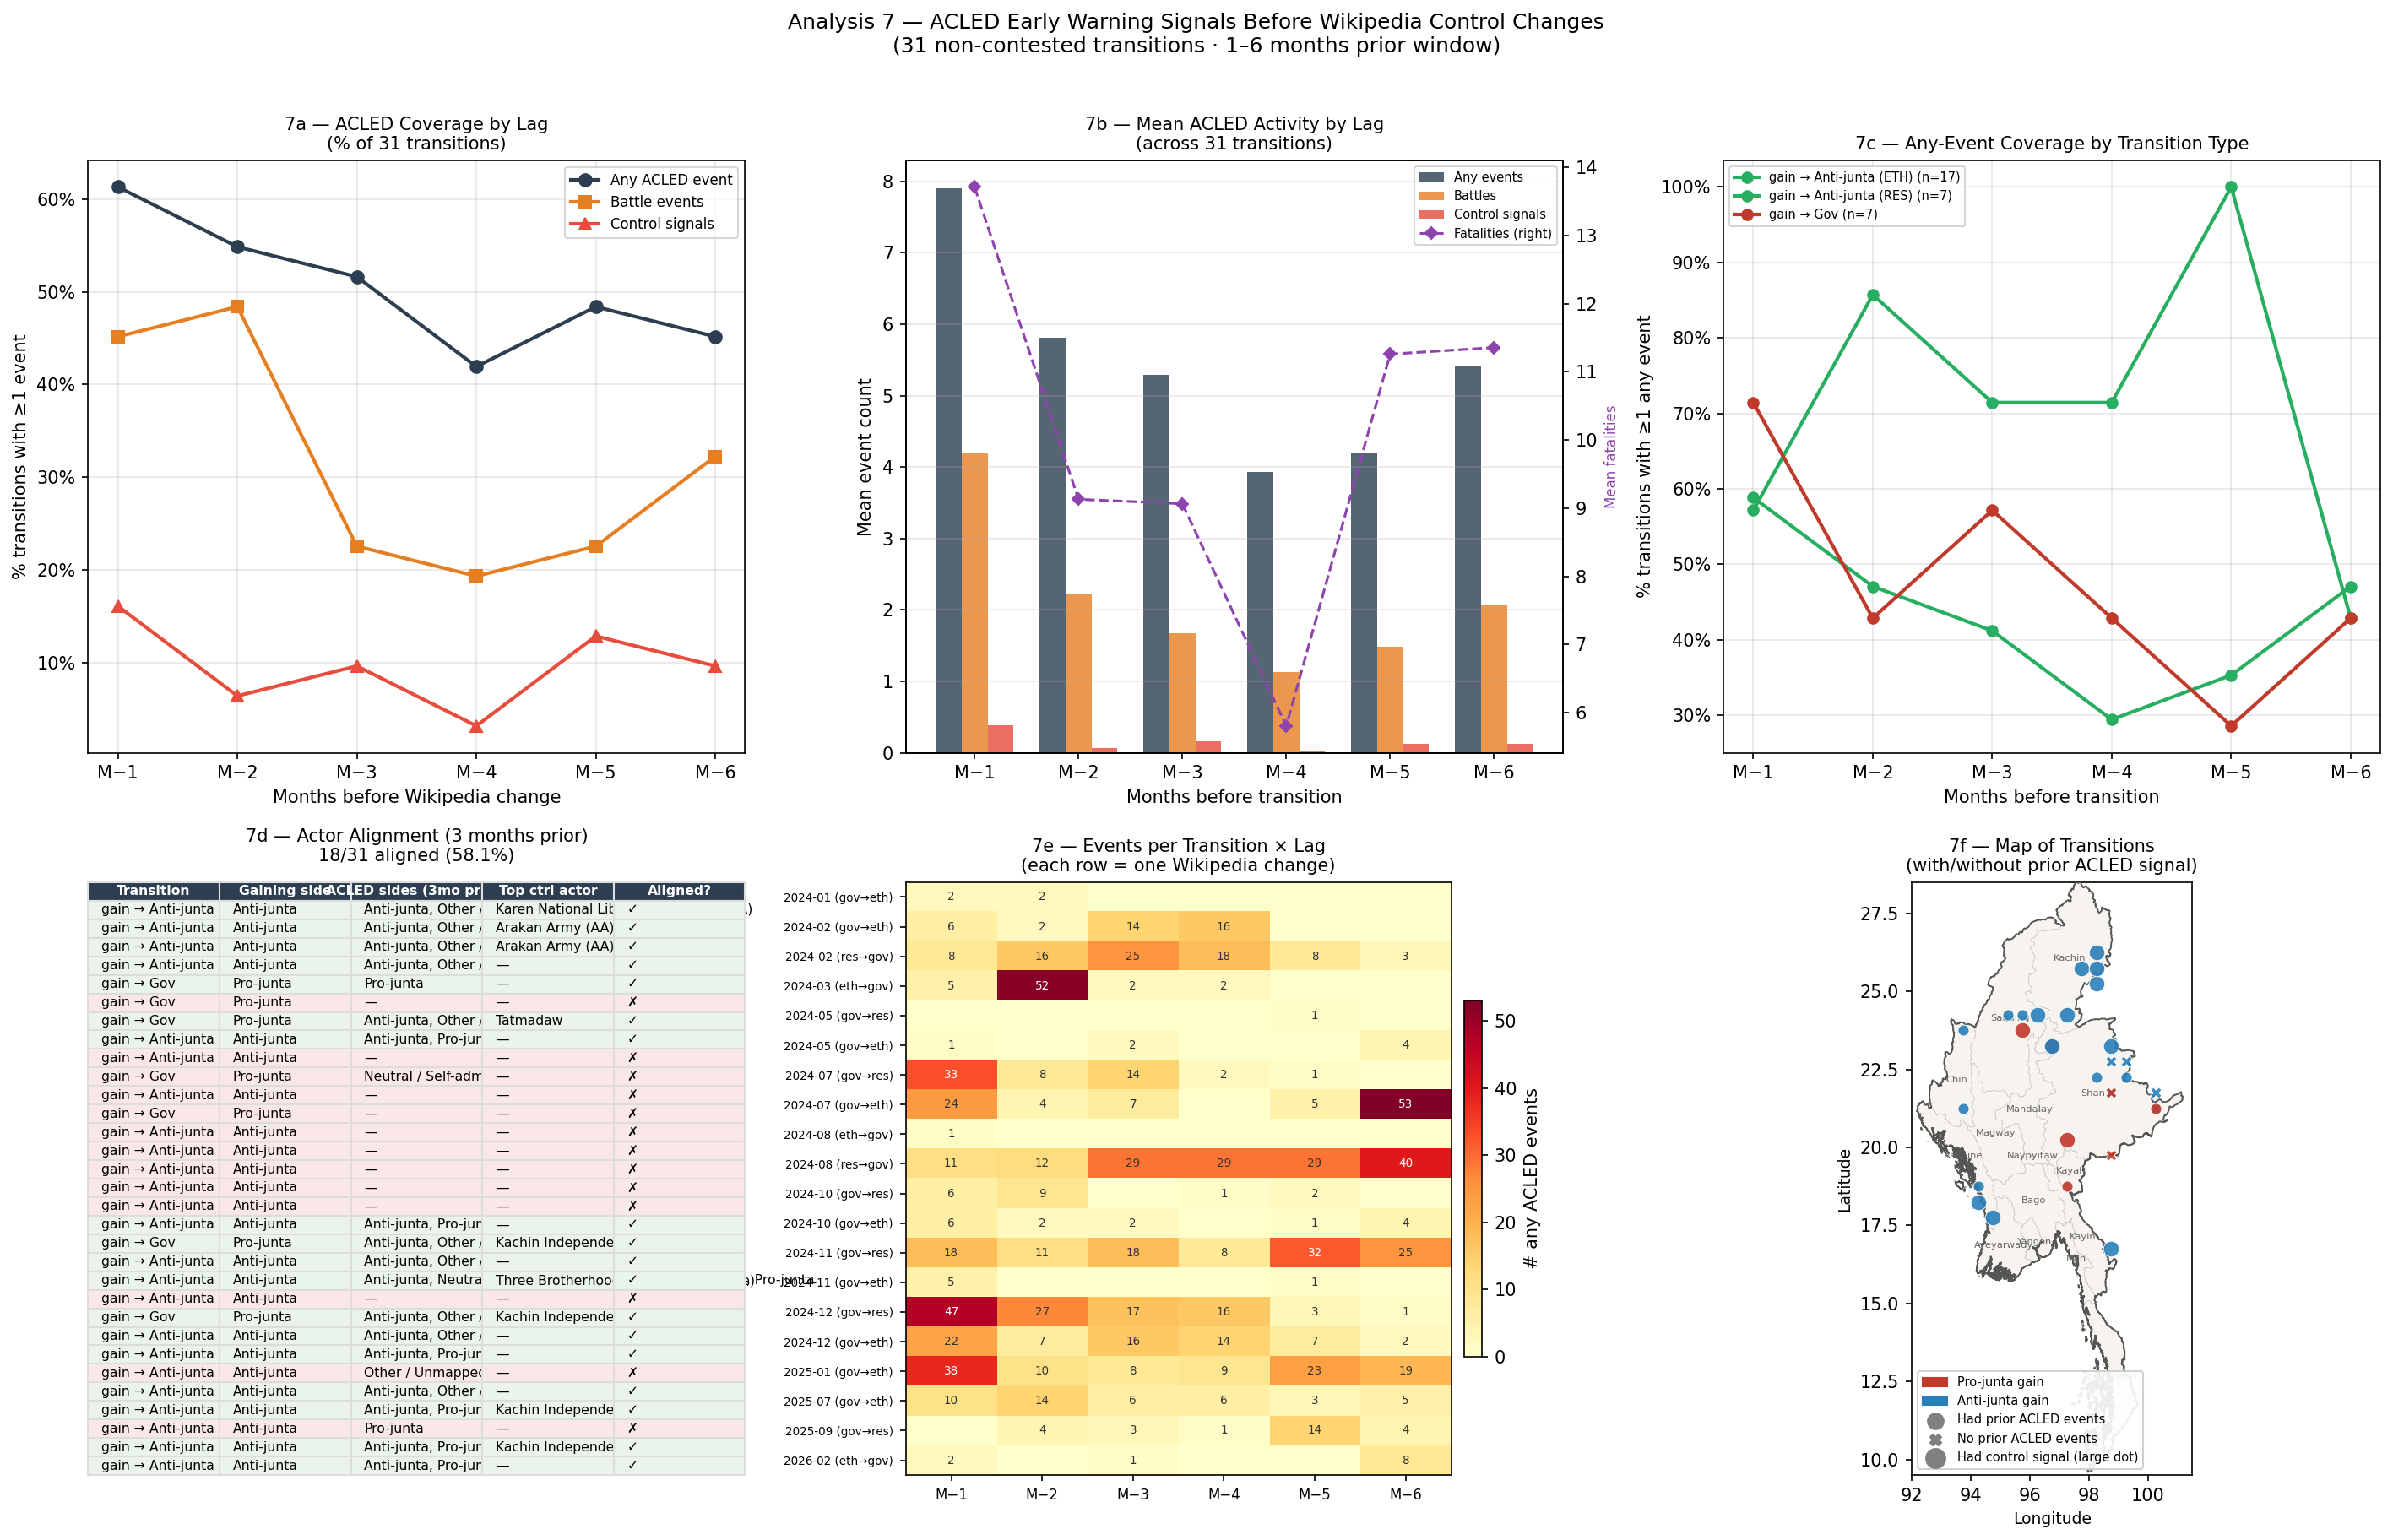

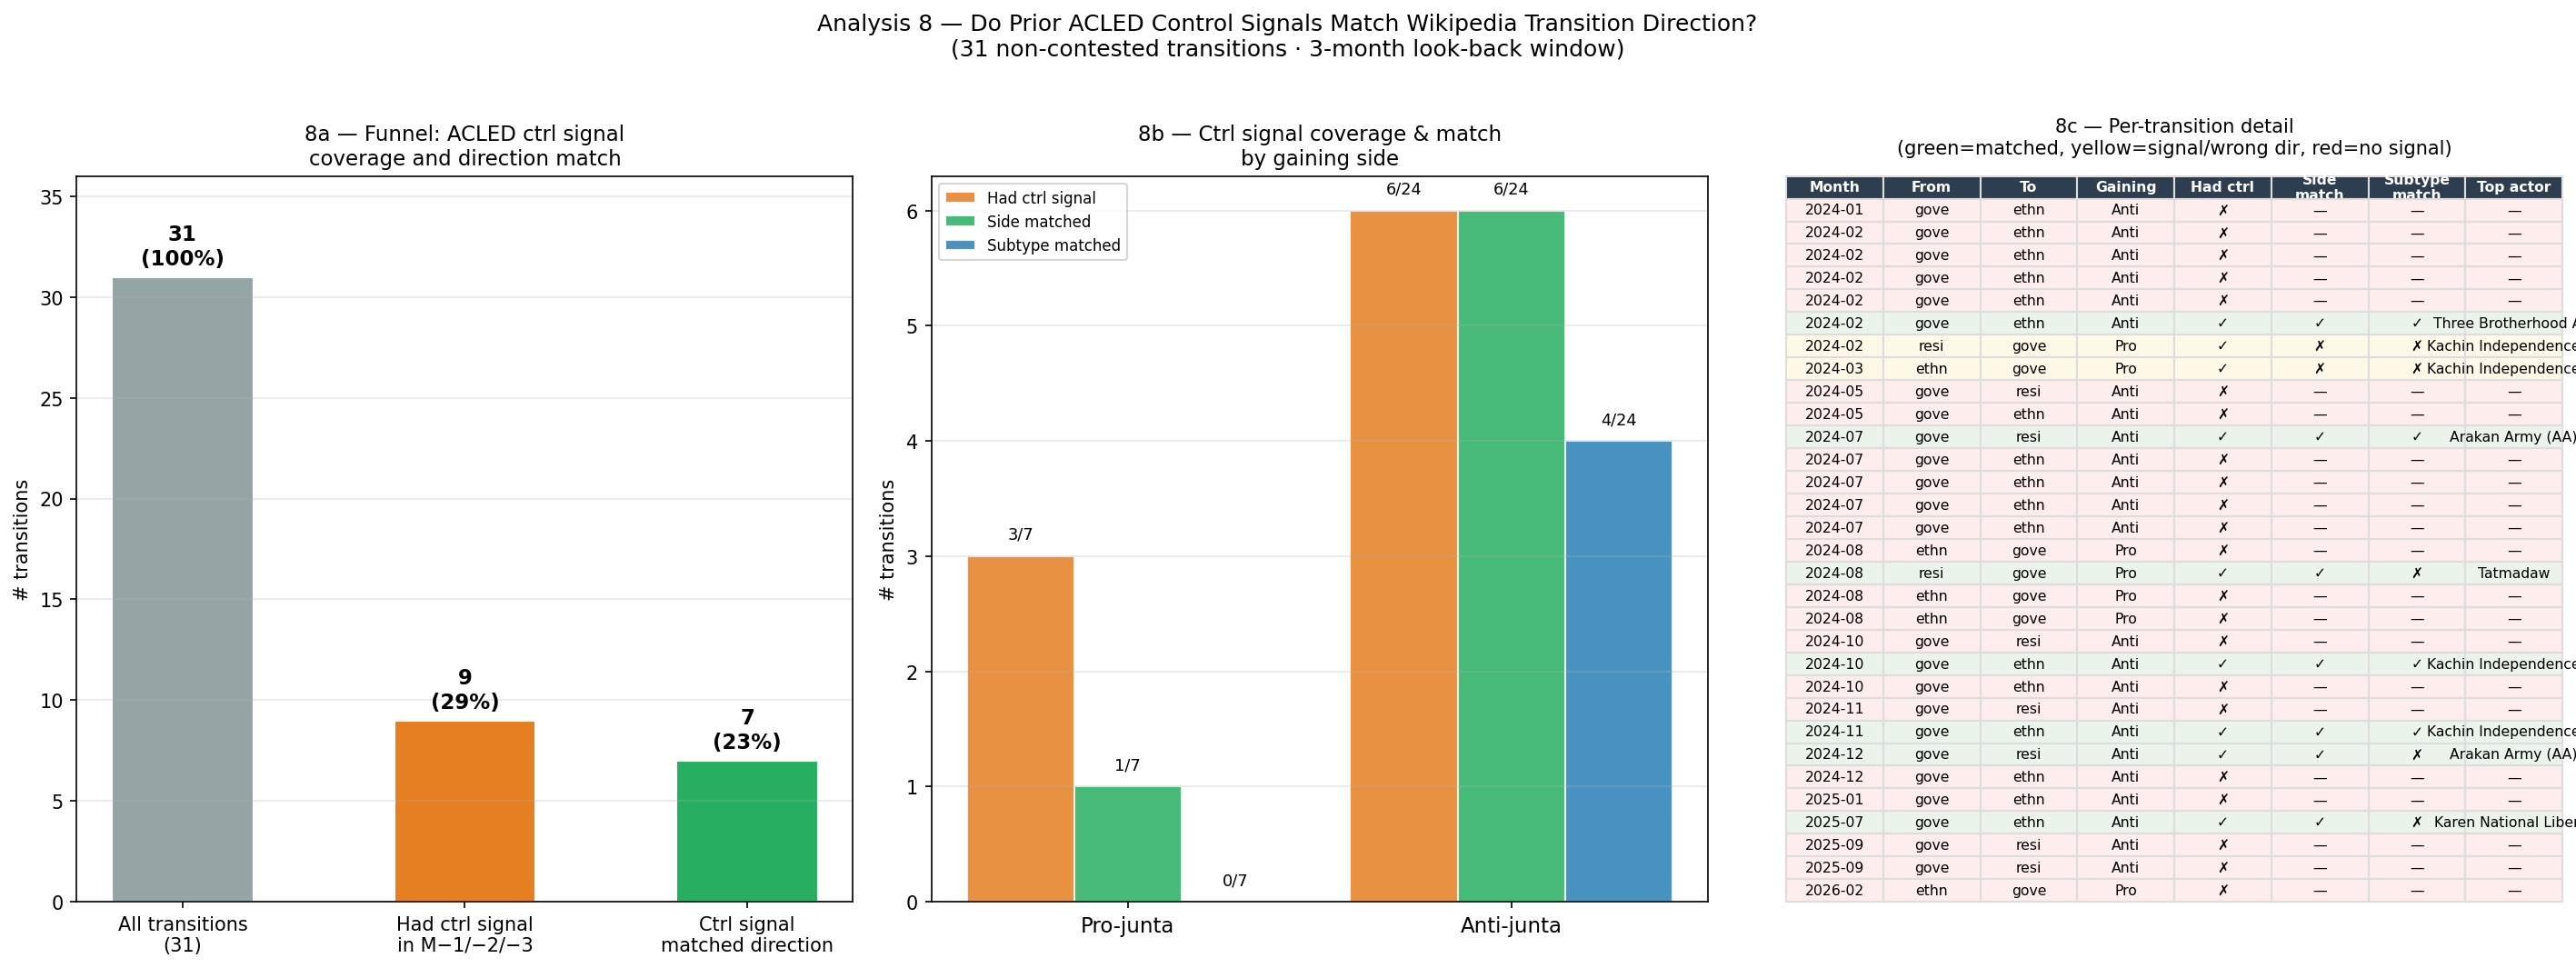

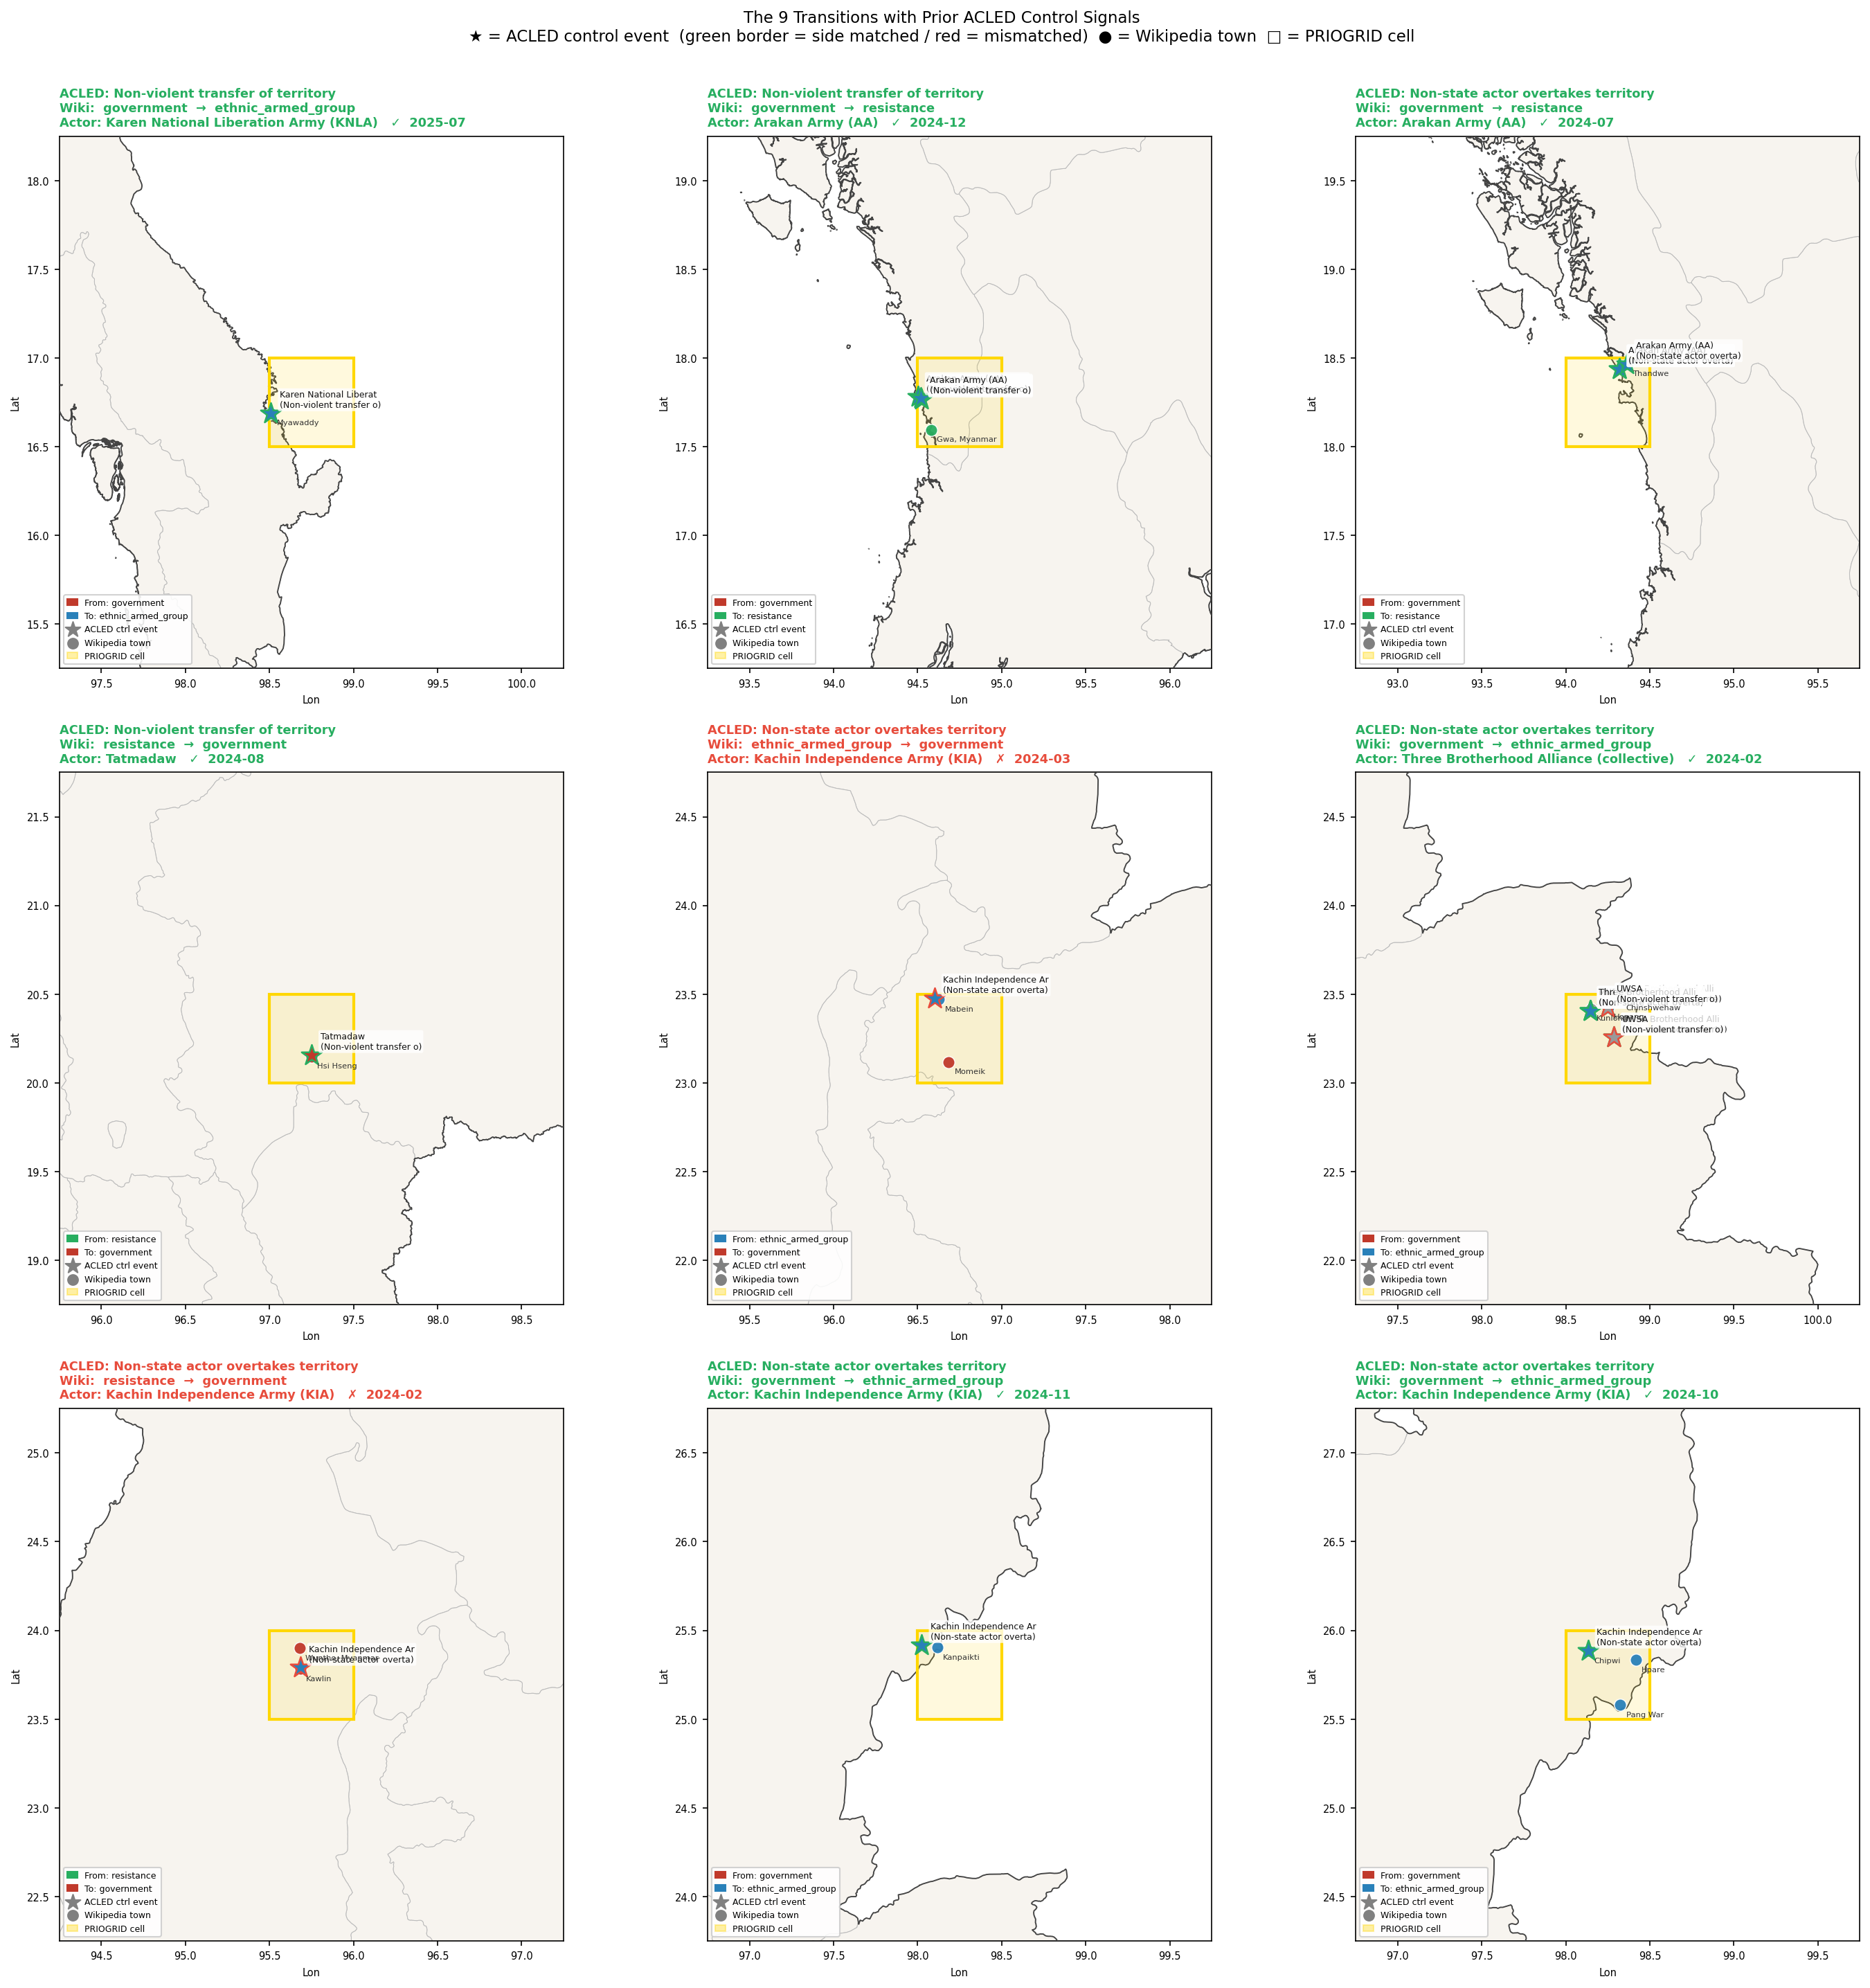

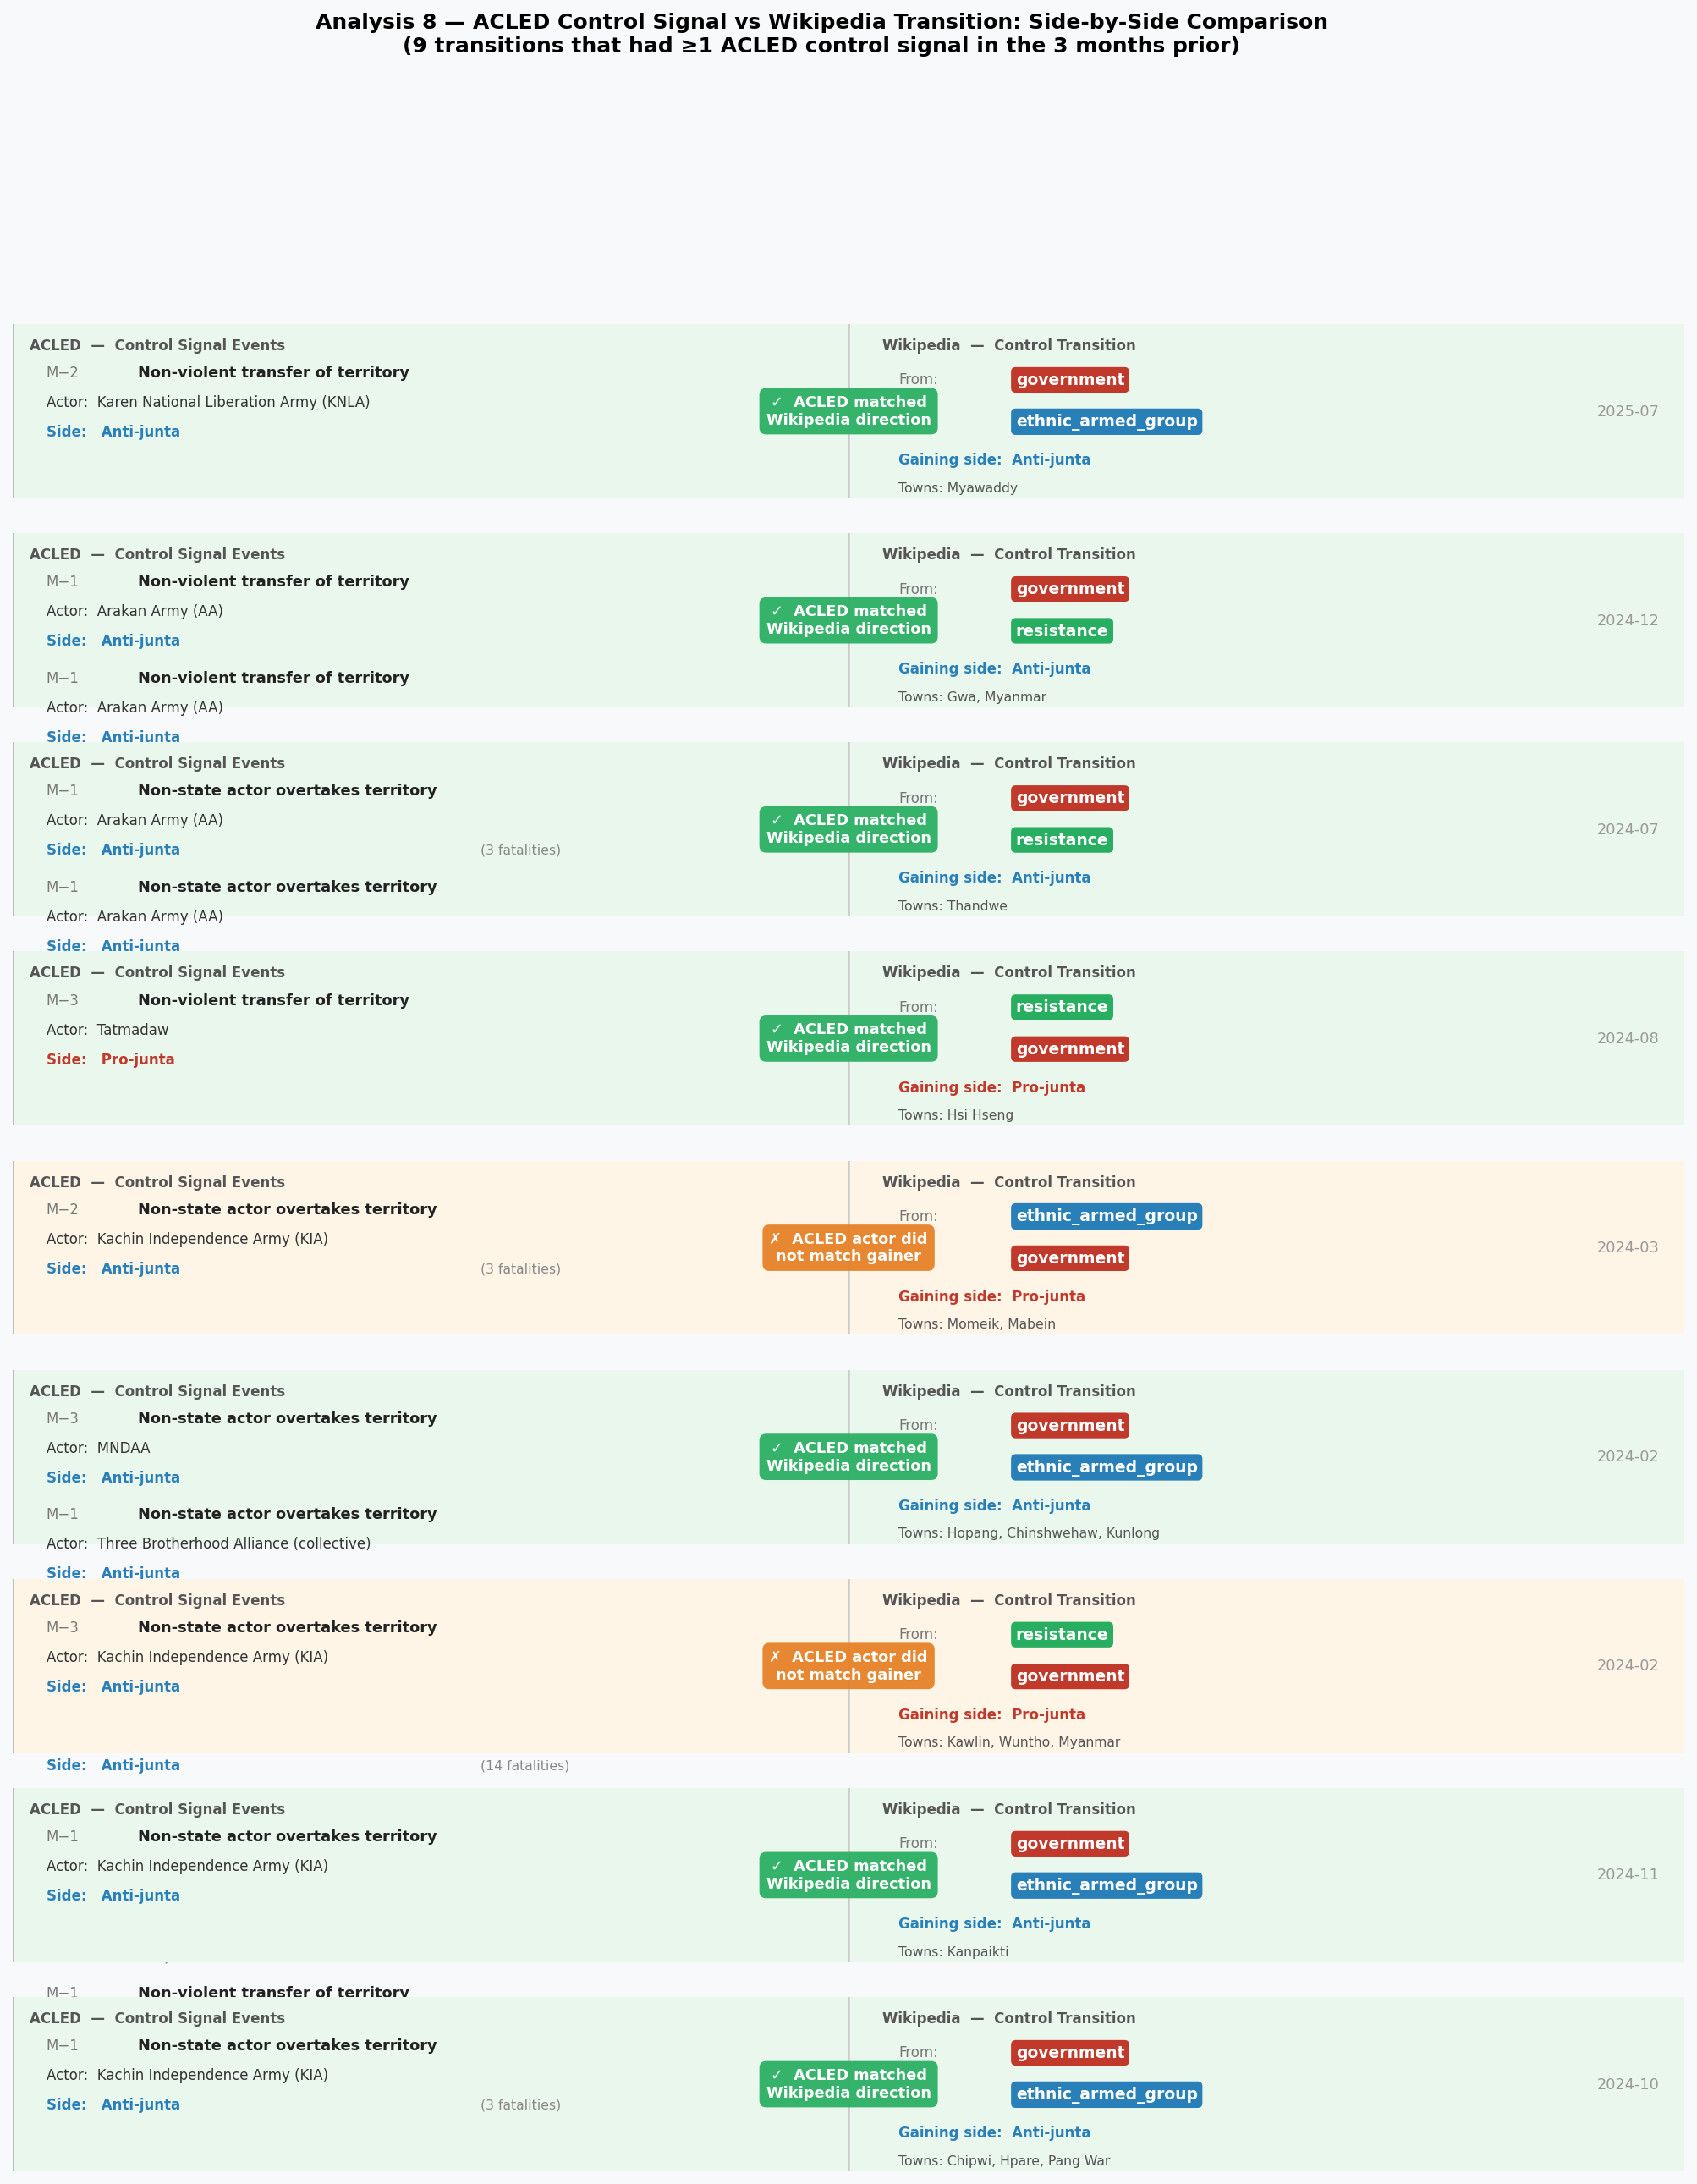

In [5]:
display(Image(str(FIG / 'analysis7_early_warning.png'), width=1200))
display(Image(str(FIG / 'analysis8_ctrl_signal_match.png'), width=1200))
display(Image(str(FIG / 'analysis8_ctrl_signal_maps.png'), width=1200))
display(Image(str(FIG / 'analysis8_comparison_cards.png'), width=1200))

## Section 5 — Wikipedia Following ACLED: Does Wikipedia Confirm ACLED Control Signals? (Analysis 9)

### Research Direction (Reversed)

This analysis inverts the temporal logic of Section 4. Instead of asking whether ACLED precedes Wikipedia transitions, we start from **every ACLED control-signal event** and ask whether the Wikipedia cell label updates to reflect the claimed gain within a three-month window (M, M+1, M+2, M+3). This operationalises the hypothesis that Wikipedia is a lagged confirmation of on-the-ground changes recorded in real time by ACLED.

### Scope

**380 ACLED control-signal events** meet all eligibility criteria: `side ∈ {Pro-junta, Anti-junta}`, located in a PRIOGRID cell with at least one Wikipedia town, and occurring within the Wikipedia observation window (November 2023 – March 2026).

### Matching Logic

The expected Wikipedia status depends on the event's `side` coding:

- **Anti-junta ACLED event** → expected Wikipedia status ∈ {`resistance`, `ethnic_armed_group`} (either resistance group type constitutes confirmation)
- **Pro-junta ACLED event** → expected Wikipedia status = `government`

An event is **confirmed at lag k** if `cell_lkup[(gid, M+k)] ∈ expected_set`, where `cell_lkup` is a pre-built dictionary from `myanmar_priogrid_labels.csv`. The aggregate flag `any_conf = conf_M OR conf_M1 OR conf_M2 OR conf_M3` captures whether confirmation occurs at any lag within the window.

### Findings

**Overall confirmation rate: 171/380 (45%) within M–M+3.**

Temporal distribution of first confirmation:
- **112 events** already confirmed at M — Wikipedia already showed the correct side at the time of the ACLED event, suggesting these represent durable control areas already recognised by both sources.
- **35 first confirmed at M+1** — a one-month Wikipedia lag.
- **16 first confirmed at M+2**
- **8 first confirmed at M+3**

**209 events (55%) are never confirmed** within the window. The breakdown of these unconfirmed cases is analytically critical:

| Category | Count | % of unconfirmed |
|----------|-------|------------------|
| Wikipedia showed the **opposing side** throughout | 120 | 57% |
| Wikipedia showed `contested` | 78 | 37% |
| No Wikipedia coverage in cell | 11 | 5% |

**Junta vs Anti-junta comparison:** Confirmation rates are similar when M is included in the window (approximately 44% Anti-junta, 48% Pro-junta). This contradicts a naive reading of the direction-matching results (Analysis 8), where Pro-junta events appeared better documented. The earlier asymmetry reflects a different phenomenon: Tatmadaw operations are confirmed at a similar rate, but they *generate the specific ACLED control-signal sub-event types less frequently*, making the pool of Pro-junta control signals smaller and harder to compare directly.

### Key Insight

The dominant reason ACLED events go unconfirmed by Wikipedia is **not missing data** — only 5% of unconfirmed events lack Wikipedia coverage entirely. The primary driver is **substantive source disagreement**: in 57% of unconfirmed cases, Wikipedia explicitly showed the *opposing* actor in control throughout the M–M+3 window. This has direct implications for how Wikipedia should be used as ground-truth: researchers should not assume that an unconfirmed ACLED event reflects a data gap. More often, it reflects a genuine editorial disagreement about who holds territorial control.

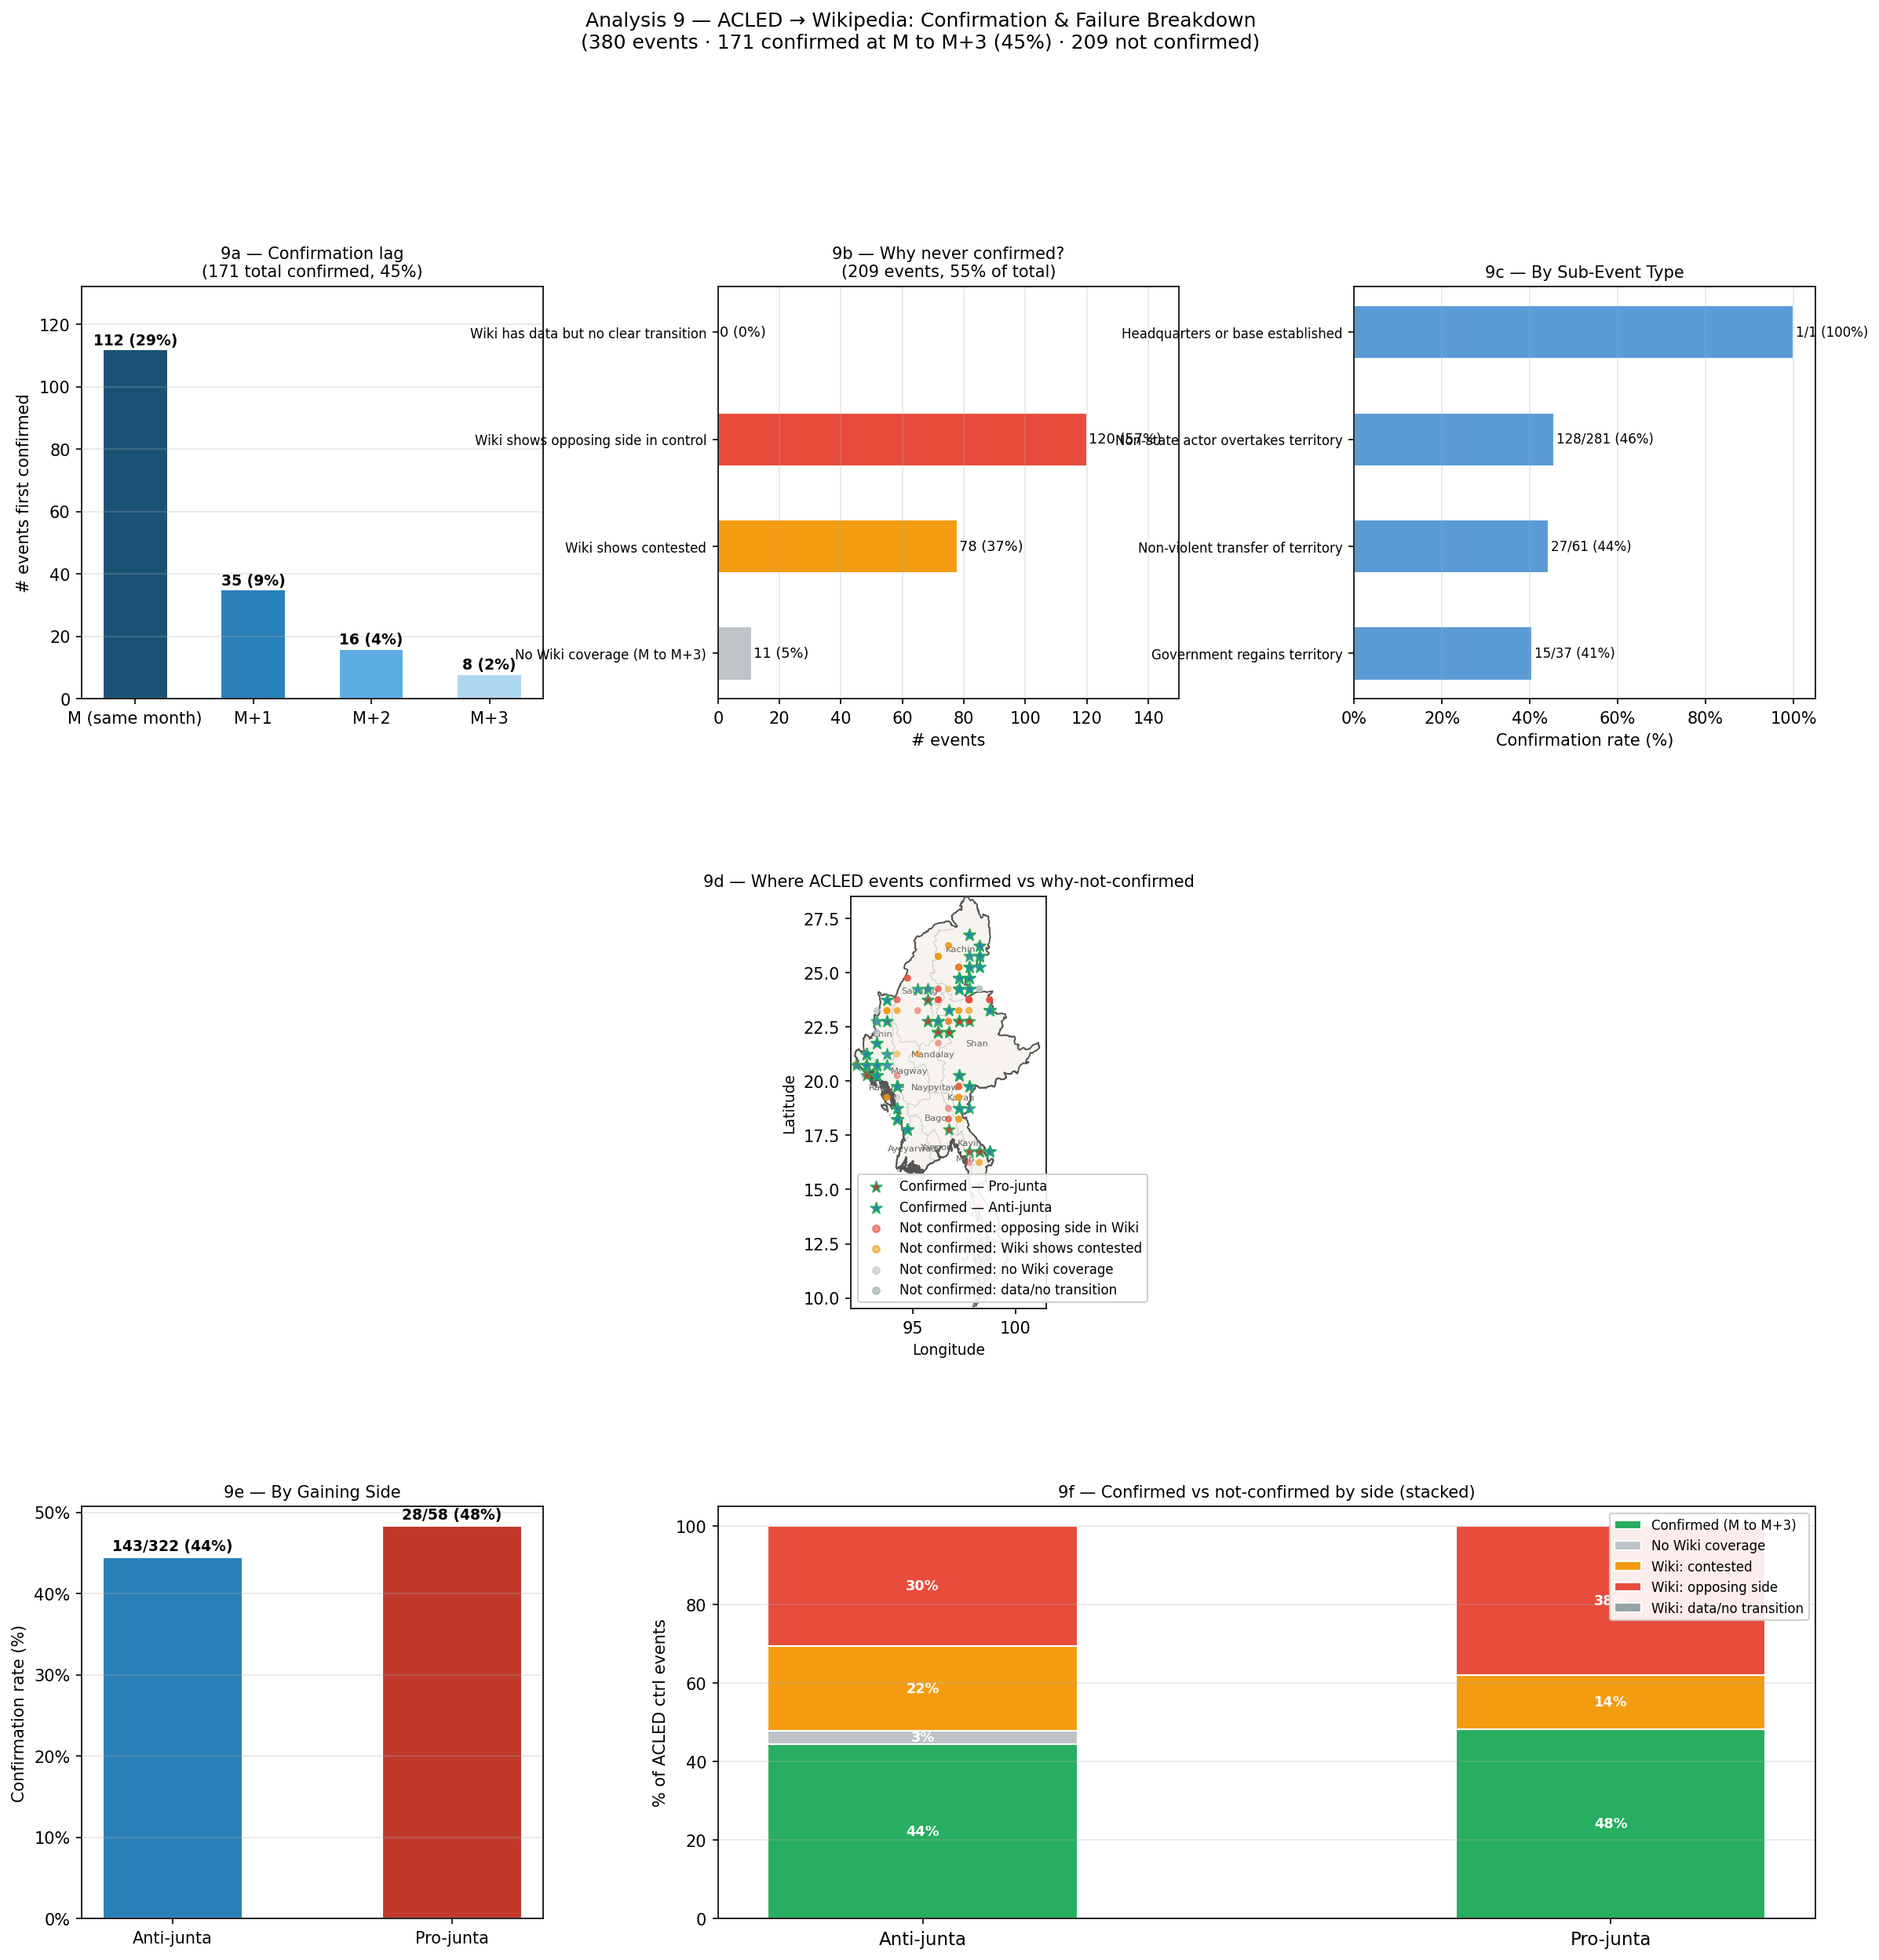

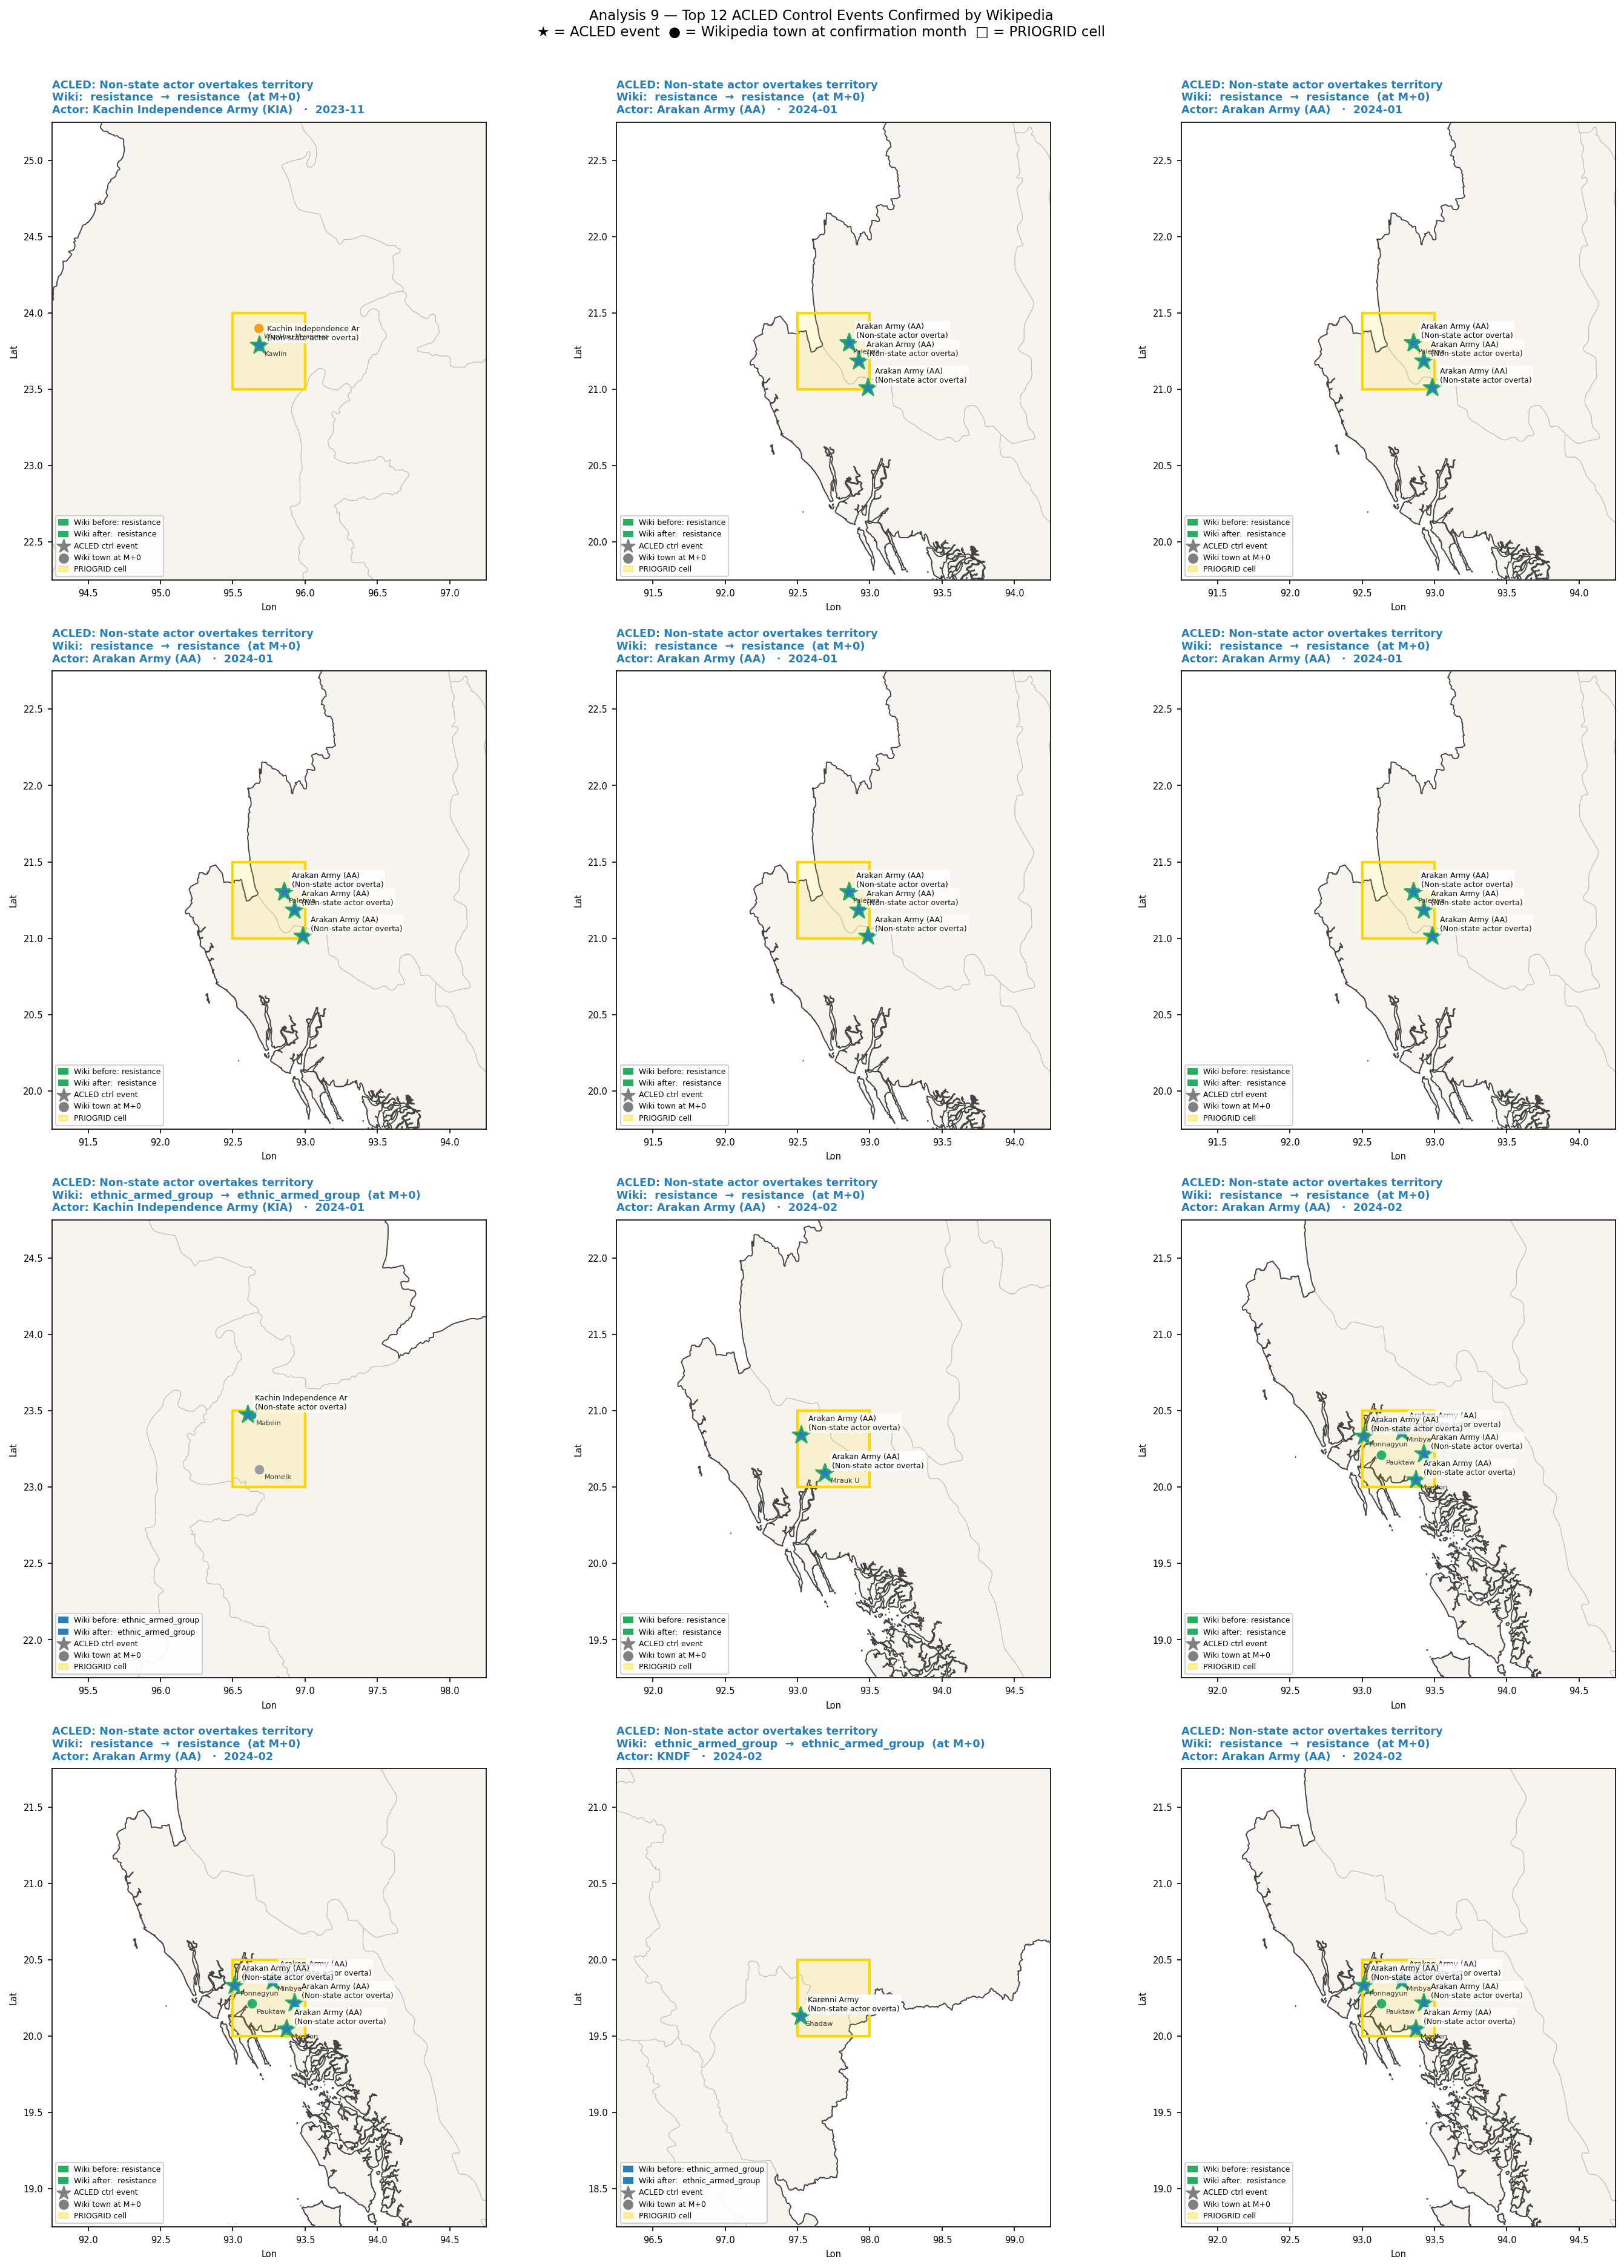

In [6]:
display(Image(str(FIG / 'analysis9_acled_to_wiki.png'), width=1200))
display(Image(str(FIG / 'analysis9_confirmed_maps.png'), width=1200))

## Section 6 — Mapping ACLED–Wikipedia Disagreement (Analysis 9b)

### What These Maps Show

Analysis 9b focuses on the **120 cases of substantive disagreement** identified in Analysis 9 — events where Wikipedia explicitly showed the opposing side in control throughout the M–M+3 window following an ACLED control-signal event. These are not ambiguous `contested` cases; they are cases where the two sources make contradictory definitive claims about who controls a location. The top 20 are selected by reported fatalities to prioritise high-stakes disagreements.

### How to Read Each Map

Each panel depicts a single PRIOGRID cell at the time of a specific ACLED–Wikipedia disagreement:

- **★ (star, red border):** ACLED control-signal event location. The sub-event type and reporting actor are shown in the panel title.
- **● (circles):** Wikipedia towns within or near the cell, coloured by their Wikipedia-assigned control status at the event month: **red = government**, **blue = ethnic\_armed\_group**, **green = resistance**.
- **Yellow box:** The 0.5°×0.5° PRIOGRID cell boundary.
- **Title format:** `ACLED: {sub_event_type}` / `Wiki: {status shown} (disagrees)` / `Actor: {name} | {month}`

### Pattern Visible in Maps

Nearly all top-20 disagreements involve **Anti-junta ACLED events** — specifically EAG or resistance forces claiming to take territory — in cells that **Wikipedia continues to label as government-controlled**. This is the core source tension in the Myanmar conflict data:

ACLED coders record non-state actor advances at the time they are reported (typically within days of the event, based on multiple media sources). Wikipedia editors, by contrast, maintain the government label in many such cells — either because the change was not yet visible to the editors updating the Wikipedia article, because they apply a stricter standard for *durable* control versus a temporary advance, or because the Wikipedia article's update cycle does not capture sub-monthly changes in frontline positions.

This asymmetry — ACLED records non-state gains, Wikipedia maintains government labels — is the single most important systematic bias for researchers using the Wikipedia ground-truth. It implies that **government cells in contested regions are likely over-represented** in the Wikipedia dataset relative to the actual distribution of territorial control, particularly in theatres of rapid non-state actor advance such as Rakhine State and parts of Sagaing.

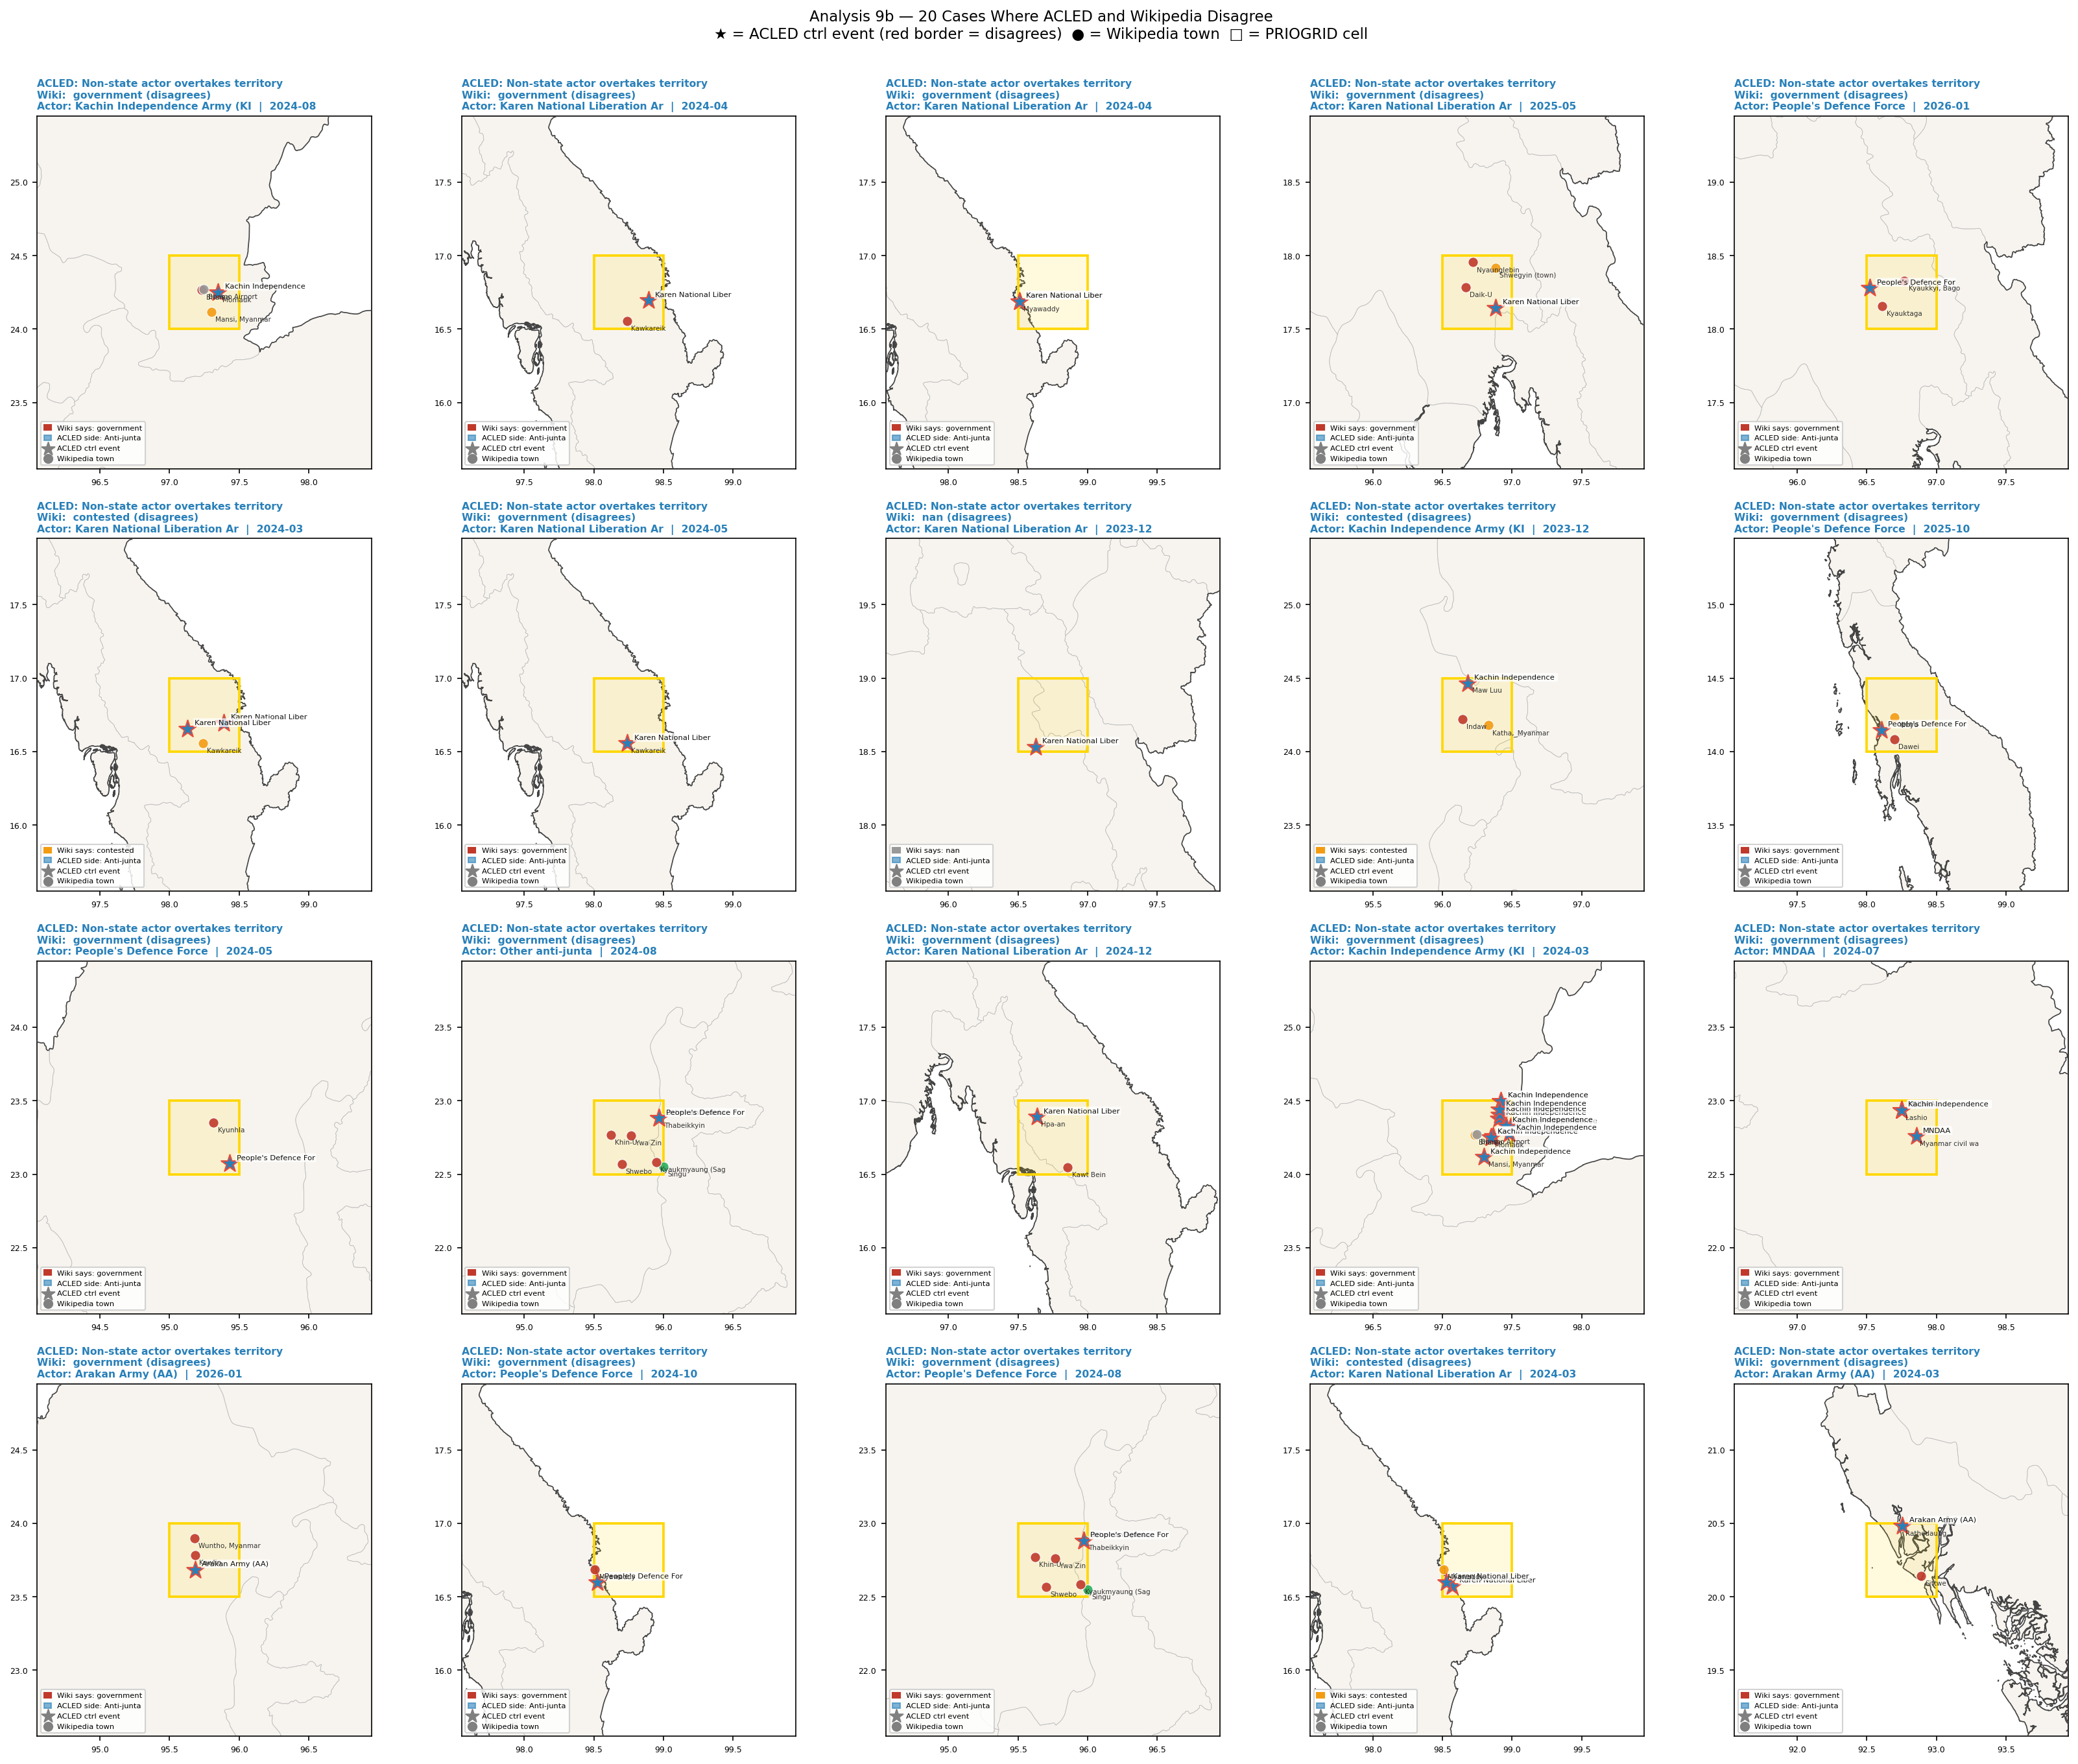

In [7]:
display(Image(str(FIG / 'analysis9b_disagreement_maps.png'), width=1200))

## Section 7 — Summary of Findings

The table below consolidates the key quantitative findings across all analyses:

| Analysis | Question | Key finding |
|----------|----------|-------------|
| 1–5 | Why is cell-level agreement low (~26% full match)? | Not spatial — median ACLED-to-wiki distance is 1.8 km. Temporal lag explains some but not all; disagreement is predominantly substantive. |
| 6 | How dynamic is the Wikipedia ground-truth? | 1.9% of cell-months show a transition; government spells dominate (median 29 months). 101 total transitions across 185 cells in 29 months. |
| 7 | Do ACLED events precede Wikipedia transitions? | 61% of the 31 non-contested transitions had ≥1 ACLED event in M−1. Coverage signal decays by M−4. |
| 8 | When they co-occur, do they agree on direction? | 7/9 (78%) of transitions with a prior ACLED control signal had matching direction. |
| 9 | Does Wikipedia confirm ACLED control signals? | 45% confirmed within M–M+3. 55% unconfirmed — but 94% of those had Wikipedia coverage; the source simply disagreed. |
| 9b | What does disagreement look like spatially? | Concentrated in EAG-contested government cells; Anti-junta advances recorded by ACLED are not reflected in Wikipedia labels. |

### Implications for Using Wikipedia as Ground-Truth

Wikipedia provides reliable, well-structured territorial control labels for the towns it covers. The dataset's 352-town, 24-snapshot structure is a substantial empirical contribution, and the explicit `contested` label (with actor-level detail) captures a dimension of conflict that most ground-truth datasets lack. However, the validation analysis reveals two systematic blind spots:

1. **Lagged recognition of non-state actor advances:** Wikipedia lags ACLED by approximately 1–3 months when non-state actors gain new territory. The ~61% ACLED-in-M−1 coverage rate (Analysis 7) and the 35-event M+1 confirmation count (Analysis 9) both point to this.

2. **Persistent government labelling in contested areas:** In 57% of ACLED-unconfirmed cases (120 of 209), Wikipedia maintained an opposing — typically government — label throughout the M–M+3 window. This is not a timing issue; it reflects a more stringent Wikipedia editorial standard for what constitutes durable territorial control, or systematic under-update in rapidly changing theatres.

**Recommended adjustments for researchers using Wikipedia as ground-truth:**

- **Treat government labels in contested regions with caution**, especially in Sagaing and Mandalay where agreement with ACLED is lowest. Consider sensitivity analyses that recode borderline government cells as `contested`.
- **Weight direct-snapshot months more heavily than LOCF-filled months** when constructing training labels or evaluation benchmarks. LOCF months do not represent independent observations and may propagate outdated labels.
- **Do not interpret ACLED–Wikipedia disagreement as noise** — in ~94% of unconfirmed ACLED control events there is an active Wikipedia label, and that label disagrees substantively. This is a feature of the data worth modelling, not an artefact to be filtered.
- **Avoid treating Anti-junta gains as systematically under-documented** at the confirmation-rate level — rates are similar for Pro- and Anti-junta events at ~45%. The directional asymmetry appears primarily in which sub-event *types* ACLED applies to each side, not in Wikipedia's overall coverage.